# Train and evaluate ocDI task on individual and concatenated datasets - noprep

In [1]:
import json
import os
from functools import partial

In [2]:
import pandas as pd
from sklearn.svm import LinearSVC

In [3]:
from ocdi.split import load_csv
from ocdi.labels import LABEL_SCHEME_TO_MAPPER
from ocdi.svm import preprocessing, train, evaluation, save
from ocdi.evaluate import get_scores_from_preds, get_baseline_theoretic_scores_uniform

In [4]:
model_prefix = "svm-noprep"
models_folder = f"ocDI_models/{model_prefix}"
os.makedirs(models_folder, exist_ok=True)
model_pattern = f"{model_prefix}_{{dataset}}"
scores_folder = "scores"
os.makedirs(scores_folder, exist_ok=True)
scores_path = f"{scores_folder}/{model_prefix}-scores.json"

In [5]:
data_root_folder = "../../ocdi_data"
dataset_folders = {
    "concatnowiki": "splitv1",
    "concat": "splitv1",
    "wiki": "splitv1",    
    "congres": "splitv1",
    "soft": "splitv1",
    "ttb": "splitud217",
    "forum": "splitv1"
}
dataset_to_labelscheme = {
    "concatnowiki": "fasttext",
    "concat": "fasttext",
    "wiki": "wiki",    
    "congres": "congres_stripped",
    "soft": "congres_stripped",
    "ttb": "ttb",
    "forum": "forum"
}
train_datasets = list(dataset_to_labelscheme)

In [6]:
def get_model_path_from_dataset_name(dataset_name):
    model_name = model_pattern.format(dataset=dataset_name)
    # Get model path
    path_model = os.path.join(
        models_folder, 
        model_name+".pickle"
    )
    return path_model

In [7]:
def load_dataset(dataset_name, split):
    # Get path
    split_date = dataset_folders[dataset_name]
    path = os.path.join(
        data_root_folder, 
        dataset_name, 
        f"{dataset_name}_{split_date}", 
        f"{dataset_name}_{split}.csv")

    # Load CSV
    df = load_csv(path)
    
    # Norm labels
    label_scheme = dataset_to_labelscheme[dataset_name]
    label_mapper = LABEL_SCHEME_TO_MAPPER[label_scheme]
    df["dialect"] = df["dialect"].map(label_mapper)
    
    return df

# Train all models

## Set preprocessing and training hyperparameters

In [8]:
# Configure preprocessing pipeline
preprocessing_params = {
    "words_pipeline": {
        "vectorizer_type": "tfidf",
        "use_idf": True,
        "preprocessor": None,
        "ngram_range": (1, 1),
        "binary": False,
        "min_df": 2,
        "max_df": 0.9,
        "norm": "l2",
        "sublinear_tf": True,
        "token_pattern": None
    },
    "chars_pipeline": {
        "vectorizer_type": "tfidf",
        "preprocessor": None,
        "ngram_range": (2, 5),
        "use_idf": True,
        "min_df": 2,
        "max_df": 0.9,
        "norm": "l2",
        "sublinear_tf": True,
        # "token_pattern": None
    }
}

In [9]:
model_hyperparams = {"max_iter": 2000, "class_weight": "balanced"}  # LinearSVC

In [10]:
def train_ngram_model_on_dataset(dataset_name):
    # Look for already trained model
    model_path = get_model_path_from_dataset_name(dataset_name)
    if os.path.exists(model_path):
        clf_pipeline = save.load_sklearn_pipeline(model_path)
        print(f"Loaded existing model from {model_path}")
    
    else:
        # Load training data
        df_train = load_dataset(dataset_name, "train")
    
        # Set the preprocessing pipeline
        preprocess_pipeline, words_transformer, chars_transformer = preprocessing.make_preprocess_pipeline(
            preprocessing_params, tokenizer=preprocessing.tokenize_text
        )
    
        # Train model
        model = LinearSVC(**model_hyperparams)  
        clf_pipeline = train.train_model(preprocess_pipeline, model, df_train, label_col="dialect")
    
        # Save model to file
        save.save_sklearn_pipeline(clf_pipeline, model_path)
        print(f"Model saved to {model_path}")

    return clf_pipeline

In [11]:
def show_top_features(clf_pipeline, n=20):
    # Show main features
    for dia, top_features in evaluation.get_top_features(clf_pipeline, n).items():
        print(f"- {dia}: {' '.join(top_features)}\n")

In [12]:
train_clfs = {}

## Concat-train

In [13]:
dataset_name = "concat"
clf_pipeline = train_ngram_model_on_dataset(dataset_name)
train_clfs[dataset_name+"-train"] = clf_pipeline
show_top_features(clf_pipeline, n=20)

Loaded existing model from ocDI_models/svm-noprep/svm-noprep_concat.pickle
- ara: w_aran w_determinants w_referéncies w_der w_comandar w_mès w_lesan w_galin w_telediario w_substantius c_∅#∅ w_adjectius w_eth w_ues w_escampar w_# w_↑ w_boira c_aran c_aran∅

- auv: w_delh w_cercar w_pueis w_3,45 w_z-es w_982 w_dreita w_26,43 w_favier w_20,17 w_gibert w_gonin w_876 c_èir w_vès w_631 c_∅cha w_inscripcions w_6,99 w_flajac

- gas: w_dens w_dab w_ei w_shens w_mei w_ua c_au w_deu w_dreta w_2019 w_dambe w_arren w_conselhèr w_suu c_au∅ w_tà w_veng c_ish w_entà w_castèth

- lan: w_sense w_del w_sul c_∅,∅ c_l∅ w_ambe c_∅, w_aude c_ièr c_iè c_al∅ w_1781 w_drecha w_… w_al w_marty w_general w_conselhièr c_∅{ w_castèl

- lim: w_maires w_daus w_quò w_queu w_'na w_ente w_quo w_quel w_833 w_quela w_emb c_∅' w_brisa w_prononciat w_caracters w_io c_:: w_15,29 w_aqui w_623

- nic: c_ou c_à∅ w_lu w_caracter w_adressa w_ligna w_statut w_recerca w_da c_ì∅ w_proprietats c_oun∅ w_prova c_oun w_finda w_gran w_@ w

In [14]:
show_top_features(clf_pipeline, n=10)

- ara: w_aran w_determinants w_referéncies w_der w_comandar w_mès w_lesan w_galin w_telediario w_substantius

- auv: w_delh w_cercar w_pueis w_3,45 w_z-es w_982 w_dreita w_26,43 w_favier w_20,17

- gas: w_dens w_dab w_ei w_shens w_mei w_ua c_au w_deu w_dreta w_2019

- lan: w_sense w_del w_sul c_∅,∅ c_l∅ w_ambe c_∅, w_aude c_ièr c_iè

- lim: w_maires w_daus w_quò w_queu w_'na w_ente w_quo w_quel w_833 w_quela

- nic: c_ou c_à∅ w_lu w_caracter w_adressa w_ligna w_statut w_recerca w_da c_ì∅

- pro: w_lei w_deis w_ò w_leis w_dau w_dei w_direccions c_#∅ w_premiera c_∅1

- viv: w_internes w_recèrcha w_poètz c_aa w_navigaor w_pechon w_predefinia w_segua w_mas w_mesmes



## Concatnowiki-train

In [15]:
dataset_name = "concatnowiki"
clf_pipeline = train_ngram_model_on_dataset(dataset_name)
train_clfs[dataset_name+"-train"] = clf_pipeline
show_top_features(clf_pipeline, n=20)

Loaded existing model from ocDI_models/svm-noprep/svm-noprep_concatnowiki.pickle
- ara: w_mès w_comandar w_aguest w_castelhan-aranés w_eth w_nau w_ar w_entà w_portau w_deth w_dedicat w_entàs w_lengua w_didactics w_informacion c_∅mès∅ c_mès∅ w_exercicis w_ficcion w_concèrts

- auv: w_inscripcions w_z-es w_be w_gran w_ges w_non w_rubrica w_brèvas w_darrèirs c_èi w_organizadas w_conferéncias c_èir w_fichèir w_validacion w_jornadas w_’ w_fichèirs w_creará w_corchas

- gas: w_dens w_dab w_ei w_mei w_ua c_au w_tà w_ed w_entà w_deu w_jo w_suu w_nada w_aqueth w_èi w_conte w_documentari w_fam w_aquera w_drets

- lan: w_del c_l∅ w_… w_al c_al∅ c_al c_∅_ w__ c_∅{ w_pòdon c_ls w_cal w_indica w_quicòm w_s w_res c_ièr w_trobaretz c_iè w_uèi

- lim: w_daus w_quò w_ente w_quo w_queu w_'na w_quel w_emb c_∅' w_brisa w_io w_dau w_quela w_caracters w_numero w_sei c_:: w_aqui w_principis w_queste

- nic: c_ou c_à∅ w_caracter w_adressa w_ligna w_statut w_recerca w_da w_gran c_oun c_ì∅ c_tà w_@ w_prova w_tap

In [16]:
show_top_features(clf_pipeline, n=10)

- ara: w_mès w_comandar w_aguest w_castelhan-aranés w_eth w_nau w_ar w_entà w_portau w_deth

- auv: w_inscripcions w_z-es w_be w_gran w_ges w_non w_rubrica w_brèvas w_darrèirs c_èi

- gas: w_dens w_dab w_ei w_mei w_ua c_au w_tà w_ed w_entà w_deu

- lan: w_del c_l∅ w_… w_al c_al∅ c_al c_∅_ w__ c_∅{ w_pòdon

- lim: w_daus w_quò w_ente w_quo w_queu w_'na w_quel w_emb c_∅' w_brisa

- nic: c_ou c_à∅ w_caracter w_adressa w_ligna w_statut w_recerca w_da w_gran c_oun

- pro: w_mi w_gravatar w_pròcha c_%{ w_direccions w_valides w_pron w_lei w_debutants w_tardier

- viv: w_recèrcha w_poètz w_navigaor w_pechon w_segua w_vinheta c_aa c_aas∅ w_mesmes w_sobre



## Wiki-train

In [17]:
dataset_name = "wiki"
clf_pipeline = train_ngram_model_on_dataset(dataset_name)
train_clfs[dataset_name+"-train"] = clf_pipeline
show_top_features(clf_pipeline, n=20)

Loaded existing model from ocDI_models/svm-noprep/svm-noprep_wiki.pickle
- ara: w_aran w_referéncies w_determinants w_aranés w_adjectius w_telediario w_galin w_substantius w_lesan w_twitter w_boira c_aran w_escampar w_web w_eth c_∅aran w_masculin w_ues w_der w_mandrònius

- auv: w_cercar w_delh w_pueis w_dreita w_z-es w_3,45 w_sans c_∅cha w_982 w_vès w_alh c_∅ch w_26,43 w_20,17 c_cha w_favier w_autrac w_embei w_631 w_sobelh

- gas: w_deu w_dens w_qu' w_ua w_dreta w_dab w_shens w_2019 w_conselhèr w_damb w_dambe w_castèth w_gers c_ish c_sh w_veng w_avant w_era w_suu w_crion

- lan: c_∅,∅ w_sense c_l∅ c_∅, w_del w_sul w_ambe w_drecha c_al∅ c_ièr c_iè w_es w_1781 w_general w_aude w_km² w_marty w_896 w_las c_ièr∅

- lim: w_maires w_daus w_833 w_administracion w_15,29 w_fuguet w_623 w_prononciat w_20,89 w_10,2 w_segle w_8,71 w_353 w_emb w_14,74 w_11,44 w_12,64 w_evesque w_5,56 w_12,97

- nic: w_lu w_proprietats w_finda w_li w_niça w_capítol w_totun w_annèxes w_autri w_biografias w_e w_world 

## Congres-train

In [18]:
dataset_name = "congres"
clf_pipeline = train_ngram_model_on_dataset(dataset_name)
train_clfs[dataset_name+"-train"] = clf_pipeline
show_top_features(clf_pipeline, n=20)

Loaded existing model from ocDI_models/svm-noprep/svm-noprep_congres.pickle
- ara: w_mès w_eth w_ar w_castelhan-aranés w_aguest w_nau w_comandar w_lengua c_∅eth∅ w_deth w_entàs w_des w_avem c_eth∅ w_didactics c_∅eth w_entà w_exercicis c_∅mès∅ c_mès∅

- auv: w_inscripcions w_: w_dau w_conferéncias w_bal w_espectacle w_dirèctament w_organizadas c_h3 c_h30 w_passarà c_30 w_obrador c_1h w_festenal w_detalhat w_partatge c_h15 c_h1 w_culturala

- gas: w_que c_u∅ w_dab w_dens w_tà w_ed w_ua w_deu w_ei c_au w_qui w_mei w_entà c_au∅ w_deus w_on w_ende w_suu w_qu' w_com

- lan: w_del c_l∅ w_es w_ex c_al w_amb w_⇒ w_dins w_pel w_sul w_obratge w_als w_pòdon w_se w_al c_al∅ w_aquela w_vos w_son w_occitània

- lim: w_mai w_linga w_estabilitat w_principis w_cerchar w_representativitat w_russe w_dau w_teledescharjar w_comandar w_dordonha w_daus w_dcl w_aura w_queu w_cooperacion w_decisions w_lu w_top w_veire

- pro: w_- w_dei w_dau w_signa w_; w_mutualizacion w_fuguèt w_burèu w_assemblada w_representa

## Soft-train

In [19]:
dataset_name = "soft"
clf_pipeline = train_ngram_model_on_dataset(dataset_name)
train_clfs[dataset_name+"-train"] = clf_pipeline
show_top_features(clf_pipeline, n=20)

Loaded existing model from ocDI_models/svm-noprep/svm-noprep_soft.pickle
- auv: w_z-es w_be w_gran w_ges c_èi w_rubrica w_non w_darrèirs w_’ w_validacion c_èir w_fichèir c_òvas c_òvas∅ w_aquel w_resultats c_èir∅ w_apondon c_∅be∅ w_la

- gas: w_deu w_mei w_aqueth w_autes w_aquera w_suber w_deus w_predefinidas w_nau w_shens w_dab w_ei w_perpausat w_dens w_naus c_isha w_entà w_navèth w_bloca w_nautats

- lan: c_∅{ w_s w__ w_serà c_d∅ c_∅_ w_0 w_indica w_% c_∅@∅ w_title w_contactes w_mencionat w_domeni w_jorn c_al w_publicacions w_* c_iè c_g∅

- lim: w_queu w_brisa w_caracters w_numero w_text w_cercha w_quela w_novela w_quel w_niveu w_sistema w_aura w_avans w_subre w_queste w_fichiers c_pera∅ w_adreiça w_validacion c_∅quel

- nic: c_ou c_à∅ w_caracter c_tà w_statut w_ligna w_recerca w_@ w_tapa c_oun∅ w_adressa c_ì∅ c_oun w_calendari w_prova w_lou w_dóu w_gran w_rùbrica w_passa

- pro: w_gravatar c_%{ w_valides w_pròcha w_siegue c_lon∅ w_direccions w_gpx w_afichat w_debutants w_modificacion

## TTB-train

In [20]:
dataset_name = "ttb"
clf_pipeline = train_ngram_model_on_dataset(dataset_name)
train_clfs[dataset_name+"-train"] = clf_pipeline
show_top_features(clf_pipeline, n=20)

Loaded existing model from ocDI_models/svm-noprep/svm-noprep_ttb.pickle
- gas: w_ei c_m∅ w_ua w_dens c_uta∅ w_deus c_uta w_rei w_drin w_mès w_que c_∅h w_qu' w_tà w_dab w_sho c_sh w_'i w_autes w_òmi

- lan: w_del w_es w_al c_l∅ w_se c_èt w_los w_amb w_las w_- w_res w_dels c_èt∅ c_fa w_leà w_mas w_far c_es∅ w_tota w_tant

- lim: w_quò w_io w_donc w_segond w_pus w_era w_– w_ren w_ròca w_creses w_daus w_moment w_chara w_sòr w_aviá w_; w_odor w_ai w_posicion w_vam

- pro: w_pèr w_lei w_fin w_bas w_uelhs w_me w_m' w_esposa w_sensa w_ai w_una w_taula w_arribèt w_si w_sieu w_babaròtas w_foguèt w_silò w_parlar w_siáu



## Forum-train

In [21]:
dataset_name = "forum"
clf_pipeline = train_ngram_model_on_dataset(dataset_name)
train_clfs[dataset_name+"-train"] = clf_pipeline
show_top_features(clf_pipeline, n=20)

Loaded existing model from ocDI_models/svm-noprep/svm-noprep_forum.pickle
- gas: w_dens w_mes w_ei w_dab c_∅.. c_∅... w_deu c_∅...∅ w_mei w_èi c_∅. w_jo w_ua w_deus w_quan w_suu c_∅h w_cau w_aqueth w_disi

- lan: w_… c_l∅ w_al w_amb w_cal w_res w_aquel w_del c_al∅ w_plan w_adieu w_ba w_pel w_el c_al w_dels w_> w_quicòm c_el∅ w_lèu

- lim: w_quo w_quò w_daus w_dau w_emb w_io w_'na w_sei c_∅' w_mas w_ente w_queu w_nonmas w_aqui w_far w_sabe c_cha c_∅cha w_veiqui w_.

- pro: w_lei w_mi w_dei w_aqueu w_tardier w_ò w_si w_siau w_pron w_èstre w_li w_ti c_lei w_bèu w_digues w_bòn w_pòu w_questien w_onte w_cu



# Evaluate all models on each testset

In [22]:
def evaluate_all_models_on_testset(test_name, trained_clfs):
    all_results_testset = {}
    
    # Load test data
    df_test = load_dataset(test_name, "test")

    # Compute theoretical random baseline
    all_results_testset["baseline_random"] = get_baseline_theoretic_scores_uniform(df_test)    

    # Run evaluation for each model    
    for model_name, clf_pipeline in trained_clfs.items():
        print(f"Predict and evaluate with model {model_name}")
        results = evaluation.evaluate_model(
            clf_pipeline,
            df_test,
            return_preds=False,
            show_confusion_matrix=True,
            label_col="dialect"
        )
        all_results_testset[model_name] = results
        
    return all_results_testset
    

In [23]:
def show_results_table(all_results_dict):
    # Load results in a DataFrame
    df_results = pd.DataFrame.from_dict(
        all_results_dict, orient="index"
    ).sort_values("f1_macro", ascending=False)
    return df_results

In [24]:
all_results_alltestsets = {}

## concat - test

Predict and evaluate with model concat-train
Computed all predictions in 0:00:29.693137


Classification report:
              precision    recall  f1-score   support

         ara     0.8529    0.1883    0.3085       154
         auv     0.6230    0.3781    0.4706       603
         gas     0.7649    0.8382    0.7999      1557
         lan     0.6022    0.8903    0.7184      2188
         lim     0.8183    0.7069    0.7586      1051
         nic     0.8816    0.2791    0.4239       774
         pro     0.6011    0.6749    0.6359      1409
         viv     0.6412    0.2137    0.3206       510

    accuracy                         0.6705      8246
   macro avg     0.7232    0.5212    0.5545      8246
weighted avg     0.6951    0.6705    0.6468      8246





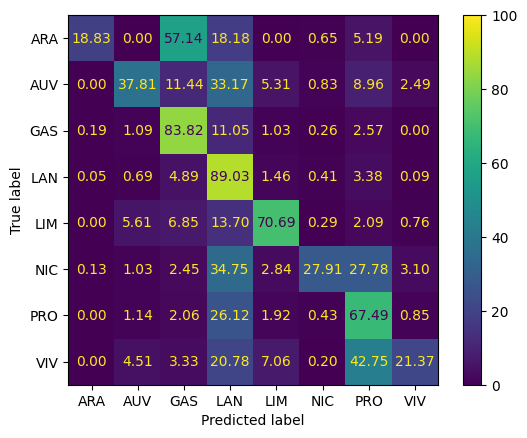

Predict and evaluate with model concatnowiki-train
Computed all predictions in 0:00:29.155680


Classification report:
              precision    recall  f1-score   support

         ara     0.7222    0.0844    0.1512       154
         auv     0.2152    0.0282    0.0499       603
         gas     0.7514    0.7861    0.7684      1557
         lan     0.4307    0.9104    0.5848      2188
         lim     0.6836    0.4605    0.5503      1051
         nic     0.7477    0.1034    0.1816       774
         pro     0.7492    0.5238    0.6165      1409
         viv     0.1684    0.0314    0.0529       510

    accuracy                         0.5535      8246
   macro avg     0.5586    0.3660    0.3694      8246
weighted avg     0.5811    0.5535    0.5025      8246





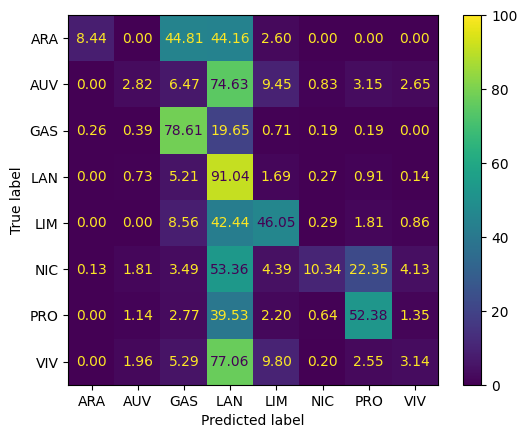

Predict and evaluate with model wiki-train
Computed all predictions in 0:00:29.371751


Classification report:
              precision    recall  f1-score   support

         ara     0.9200    0.2987    0.4510       154
         auv     0.7296    0.3715    0.4923       603
         gas     0.7248    0.7425    0.7335      1557
         lan     0.5798    0.7404    0.6503      2188
         lim     0.8673    0.5347    0.6616      1051
         nic     0.9856    0.2661    0.4191       774
         pro     0.4322    0.7800    0.5562      1409
         viv     0.9900    0.1941    0.3246       510

    accuracy                         0.6078      8246
   macro avg     0.7787    0.4910    0.5361      8246
weighted avg     0.6994    0.6078    0.5943      8246





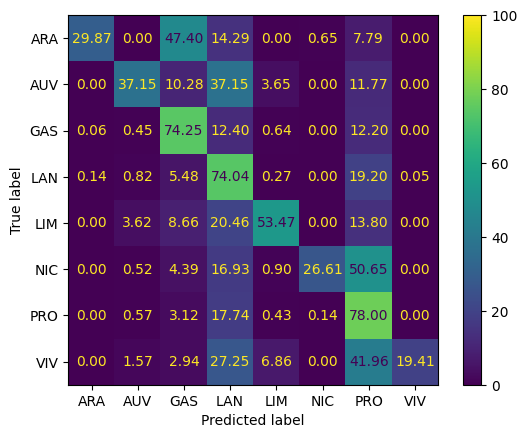

Predict and evaluate with model congres-train
Computed all predictions in 0:00:30.047495


Classification report:
              precision    recall  f1-score   support

         ara     0.7667    0.1494    0.2500       154
         auv     0.1250    0.0017    0.0033       603
         gas     0.5622    0.7842    0.6549      1557
         lan     0.3336    0.8643    0.4814      2188
         lim     0.6230    0.0723    0.1296      1051
         nic        nan    0.0000    0.0000       774
         pro     0.3959    0.0688    0.1173      1409
         viv        nan    0.0000    0.0000       510

    accuracy                         0.4013      8246
   macro avg     0.4677    0.2426    0.2045      8246
weighted avg     0.4325    0.4013    0.2928      8246





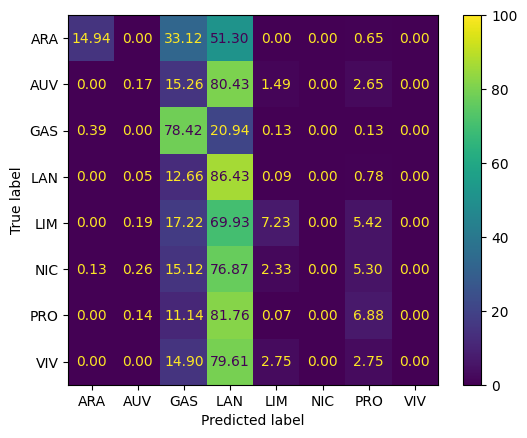

Predict and evaluate with model soft-train
Computed all predictions in 0:00:29.084133


Classification report:
              precision    recall  f1-score   support

         ara        nan    0.0000    0.0000       154
         auv     0.2188    0.0348    0.0601       603
         gas     0.8925    0.2614    0.4044      1557
         lan     0.3062    0.9680    0.4652      2188
         lim     0.5448    0.0752    0.1321      1051
         nic     0.7211    0.1370    0.2302       774
         pro     0.7351    0.1930    0.3058      1409
         viv     0.1316    0.0294    0.0481       510

    accuracy                         0.3660      8246
   macro avg     0.5072    0.2124    0.2057      8246
weighted avg     0.5469    0.3660    0.2978      8246





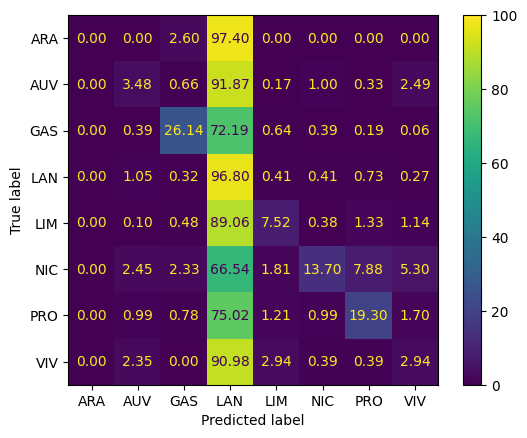

Predict and evaluate with model ttb-train
Computed all predictions in 0:00:28.838017


Classification report:
              precision    recall  f1-score   support

         ara        nan    0.0000    0.0000       154
         auv        nan    0.0000    0.0000       603
         gas     0.6674    0.6095    0.6371      1557
         lan     0.3370    0.9616    0.4991      2188
         lim     0.7255    0.1056    0.1844      1051
         nic        nan    0.0000    0.0000       774
         pro     0.7570    0.2300    0.3527      1409
         viv        nan    0.0000    0.0000       510

    accuracy                         0.4230      8246
   macro avg     0.6217    0.2383    0.2092      8246
weighted avg     0.5811    0.4230    0.3365      8246





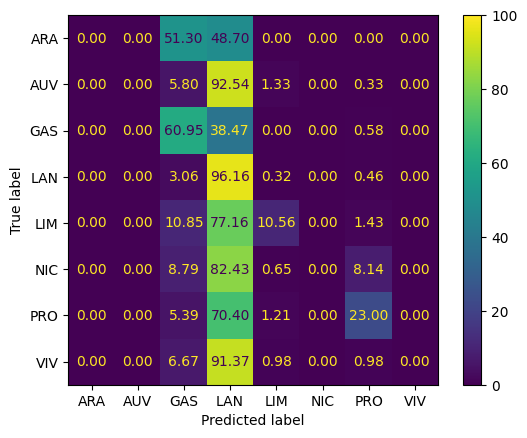

Predict and evaluate with model forum-train
Computed all predictions in 0:00:29.011551


Classification report:
              precision    recall  f1-score   support

         ara        nan    0.0000    0.0000       154
         auv        nan    0.0000    0.0000       603
         gas     0.5388    0.8337    0.6546      1557
         lan     0.6287    0.6138    0.6212      2188
         lim     0.3675    0.7336    0.4897      1051
         nic        nan    0.0000    0.0000       774
         pro     0.5296    0.6026    0.5637      1409
         viv        nan    0.0000    0.0000       510

    accuracy                         0.5167      8246
   macro avg     0.5162    0.3479    0.2911      8246
weighted avg     0.5394    0.5167    0.4472      8246





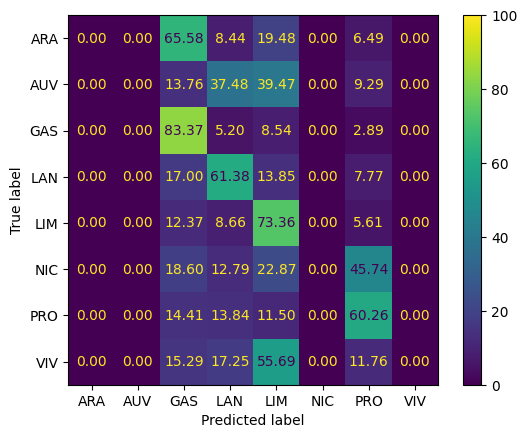

,f1_macro,accuracy,precision_macro,recall_macro,f1_ara,f1_auv,f1_gas,f1_lan,f1_lim,f1_nic,...,precision_viv,recall_ara,recall_auv,recall_gas,recall_lan,recall_lim,recall_nic,recall_pro,recall_viv,speed_avg
concat-train,0.554549,0.670507,0.723154,0.521196,0.308511,0.470588,0.799877,0.718422,0.758550,0.423945,...,0.641176,0.188312,0.378109,0.838150,0.890311,0.706946,0.279070,0.674947,0.213725,3.600914
wiki-train,0.536073,0.607810,0.778665,0.491002,0.450980,0.492308,0.733503,0.650341,0.661566,0.419125,...,0.990000,0.298701,0.371476,0.742453,0.740402,0.534729,0.266150,0.779986,0.194118,3.561939
concatnowiki-train,0.369438,0.553480,0.558554,0.366022,0.151163,0.049853,0.768362,0.584764,0.550313,0.181612,...,0.168421,0.084416,0.028192,0.786127,0.910420,0.460514,0.103359,0.523776,0.031373,3.535736
forum-train,0.291147,0.516735,0.516171,0.347950,0.000000,0.000000,0.654564,0.621184,0.489679,0.000000,...,NaN,0.000000,0.000000,0.833654,0.613803,0.733587,0.000000,0.602555,0.000000,3.518257
ttb-train,0.209171,0.422993,0.621722,0.238335,0.000000,0.000000,0.637127,0.499110,0.184385,0.000000,...,NaN,0.000000,0.000000,0.609505,0.961609,0.105614,0.000000,0.229950,0.000000,3.497213
soft-train,0.205725,0.365996,0.507155,0.212351,0.000000,0.060086,0.404372,0.465188,0.132107,0.230185,...,0.131579,0.000000,0.034826,0.261400,0.968007,0.075167,0.136951,0.193045,0.029412,3.527060
congres-train,0.204546,0.401285,0.467710,0.242578,0.250000,0.003273,0.654867,0.481354,0.129582,0.000000,...,NaN,0.149351,0.001658,0.784200,0.864260,0.072312,0.000000,0.068843,0.000000,3.643887
baseline_random,0.113212,0.125000,0.125000,0.125000,0.032496,0.092272,0.150420,0.169942,0.126216,0.107217,...,0.061848,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,NaN


In [25]:
test_name = "concat"
all_results_alltestsets[test_name] = evaluate_all_models_on_testset(test_name, train_clfs)
show_results_table(all_results_alltestsets[test_name])

## concatnowiki - test

Predict and evaluate with model concat-train
Computed all predictions in 0:00:08.144702


Classification report:
              precision    recall  f1-score   support

         ara     0.6154    0.2500    0.3556        32
         auv     0.3898    0.2255    0.2857       102
         gas     0.8247    0.8543    0.8392      1057
         lan     0.6189    0.9087    0.7363      1687
         lim     0.7846    0.7044    0.7423       548
         nic     0.8028    0.2280    0.3551       500
         pro     0.8201    0.5161    0.6335       901
         viv     0.2564    0.2083    0.2299        96

    accuracy                         0.7012      4923
   macro avg     0.6391    0.4869    0.5222      4923
weighted avg     0.7252    0.7012    0.6799      4923





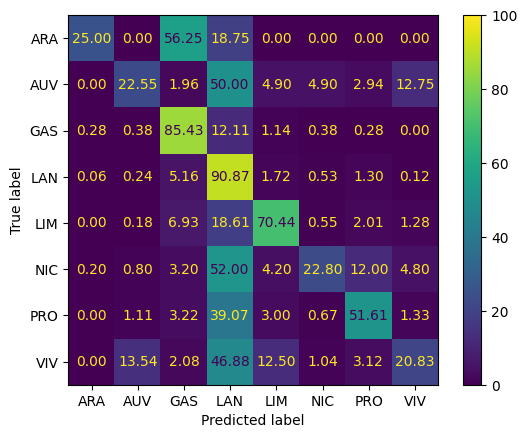

Predict and evaluate with model concatnowiki-train
Computed all predictions in 0:00:08.248367


Classification report:
              precision    recall  f1-score   support

         ara     0.4444    0.1250    0.1951        32
         auv     0.1948    0.1471    0.1676       102
         gas     0.7942    0.8581    0.8249      1057
         lan     0.6079    0.8933    0.7235      1687
         lim     0.7607    0.6788    0.7175       548
         nic     0.7477    0.1600    0.2636       500
         pro     0.8305    0.4839    0.6115       901
         viv     0.1684    0.1667    0.1675        96

    accuracy                         0.6778      4923
   macro avg     0.5686    0.4391    0.4589      4923
weighted avg     0.7017    0.6778    0.6516      4923





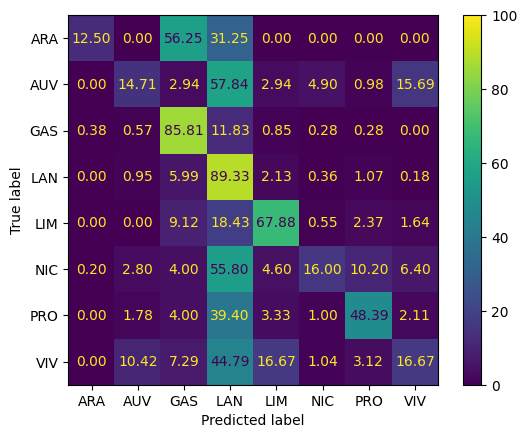

Predict and evaluate with model wiki-train
Computed all predictions in 0:00:08.168336


Classification report:
              precision    recall  f1-score   support

         ara     0.7857    0.3438    0.4783        32
         auv     0.3636    0.2745    0.3128       102
         gas     0.7743    0.7304    0.7517      1057
         lan     0.6213    0.7090    0.6622      1687
         lim     0.8745    0.3814    0.5311       548
         nic     0.9683    0.1220    0.2167       500
         pro     0.3807    0.6781    0.4876       901
         viv     0.6667    0.0208    0.0404        96

    accuracy                         0.5870      4923
   macro avg     0.6794    0.4075    0.4351      4923
weighted avg     0.6702    0.5870    0.5691      4923





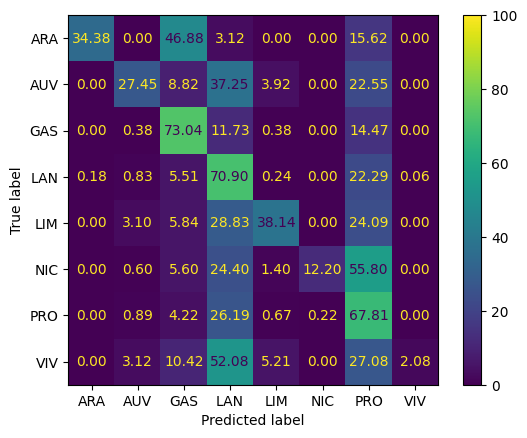

Predict and evaluate with model congres-train
Computed all predictions in 0:00:08.209526


Classification report:
              precision    recall  f1-score   support

         ara     0.5625    0.2812    0.3750        32
         auv     0.0000    0.0000    0.0000       102
         gas     0.5729    0.8477    0.6837      1057
         lan     0.4568    0.8518    0.5947      1687
         lim     0.6559    0.1113    0.1903       548
         nic        nan    0.0000    0.0000       500
         pro     0.5773    0.0622    0.1122       901
         viv        nan    0.0000    0.0000        96

    accuracy                         0.4995      4923
   macro avg     0.4709    0.2693    0.2445      4923
weighted avg     0.5255    0.4995    0.3947      4923





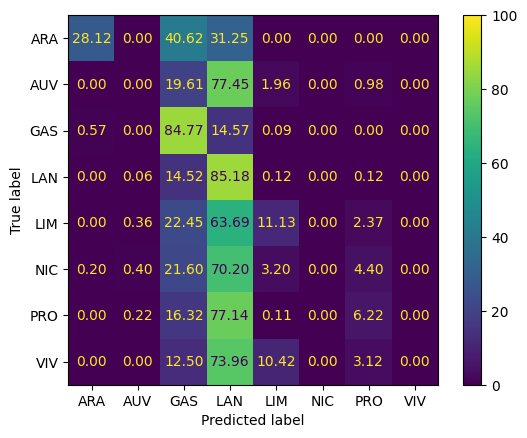

Predict and evaluate with model soft-train
Computed all predictions in 0:00:08.061019


Classification report:
              precision    recall  f1-score   support

         ara        nan    0.0000    0.0000        32
         auv     0.1935    0.1765    0.1846       102
         gas     0.8649    0.2848    0.4285      1057
         lan     0.4224    0.9585    0.5864      1687
         lim     0.5385    0.1405    0.2229       548
         nic     0.7260    0.2120    0.3282       500
         pro     0.7276    0.2075    0.3230       901
         viv     0.1389    0.1562    0.1471        96

    accuracy                         0.4715      4923
   macro avg     0.5160    0.2670    0.2776      4923
weighted avg     0.6080    0.4715    0.4169      4923





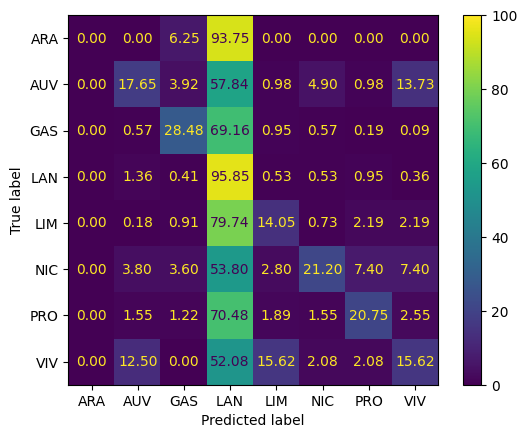

Predict and evaluate with model ttb-train
Computed all predictions in 0:00:07.964596


Classification report:
              precision    recall  f1-score   support

         ara        nan    0.0000    0.0000        32
         auv        nan    0.0000    0.0000       102
         gas     0.7249    0.6708    0.6968      1057
         lan     0.4415    0.9573    0.6043      1687
         lim     0.7742    0.1752    0.2857       548
         nic        nan    0.0000    0.0000       500
         pro     0.7485    0.1354    0.2293       901
         viv        nan    0.0000    0.0000        96

    accuracy                         0.5164      4923
   macro avg     0.6723    0.2423    0.2270      4923
weighted avg     0.6224    0.5164    0.4305      4923





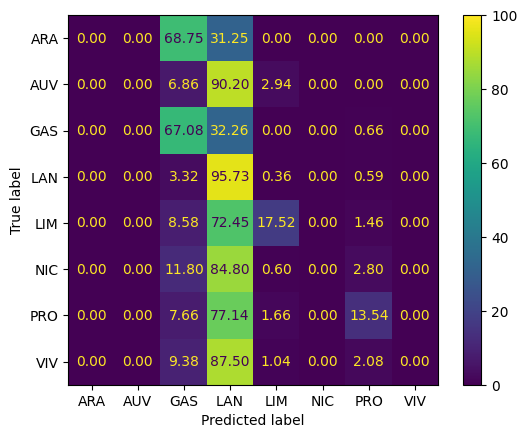

Predict and evaluate with model forum-train
Computed all predictions in 0:00:08.017620


Classification report:
              precision    recall  f1-score   support

         ara        nan    0.0000    0.0000        32
         auv        nan    0.0000    0.0000       102
         gas     0.5822    0.8647    0.6959      1057
         lan     0.6976    0.6100    0.6509      1687
         lim     0.4283    0.8175    0.5621       548
         nic        nan    0.0000    0.0000       500
         pro     0.5421    0.5006    0.5205       901
         viv        nan    0.0000    0.0000        96

    accuracy                         0.5773      4923
   macro avg     0.5625    0.3491    0.3037      4923
weighted avg     0.5999    0.5773    0.5303      4923





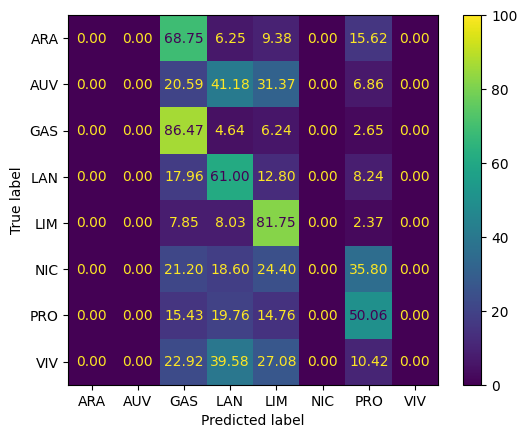

,f1_macro,accuracy,precision_macro,recall_macro,f1_ara,f1_auv,f1_gas,f1_lan,f1_lim,f1_nic,...,precision_viv,recall_ara,recall_auv,recall_gas,recall_lan,recall_lim,recall_nic,recall_pro,recall_viv,speed_avg
concat-train,0.522206,0.701198,0.639082,0.486914,0.355556,0.285714,0.839219,0.736311,0.742308,0.355140,...,0.256410,0.25000,0.225490,0.854305,0.908714,0.704380,0.228,0.516093,0.208333,1.654418
concatnowiki-train,0.458900,0.677839,0.568584,0.439107,0.195122,0.167598,0.824920,0.723476,0.717454,0.263591,...,0.168421,0.12500,0.147059,0.858089,0.893302,0.678832,0.160,0.483907,0.166667,1.675476
wiki-train,0.435114,0.587040,0.679382,0.407492,0.478261,0.312849,0.751704,0.662237,0.531131,0.216696,...,0.666667,0.34375,0.274510,0.730369,0.708951,0.381387,0.122,0.678135,0.020833,1.659219
forum-train,0.303662,0.577290,0.562540,0.349093,0.000000,0.000000,0.695851,0.650854,0.562108,0.000000,...,NaN,0.00000,0.000000,0.864711,0.609959,0.817518,0.000,0.500555,0.000000,1.628605
soft-train,0.277569,0.471460,0.515987,0.267007,0.000000,0.184615,0.428470,0.586401,0.222865,0.328173,...,0.138889,0.00000,0.176471,0.284768,0.958506,0.140511,0.212,0.207547,0.156250,1.637420
congres-train,0.244490,0.499492,0.470899,0.269276,0.375000,0.000000,0.683709,0.594662,0.190328,0.000000,...,NaN,0.28125,0.000000,0.847682,0.851808,0.111314,0.000,0.062153,0.000000,1.667586
ttb-train,0.227018,0.516352,0.672277,0.242334,0.000000,0.000000,0.696806,0.604303,0.285714,0.000000,...,NaN,0.00000,0.000000,0.670766,0.957321,0.175182,0.000,0.135405,0.000000,1.617834
baseline_random,0.100151,0.125000,0.125000,0.125000,0.012358,0.035546,0.158009,0.183180,0.117761,0.112070,...,0.019500,0.12500,0.125000,0.125000,0.125000,0.125000,0.125,0.125000,0.125000,NaN


In [26]:
test_name = "concatnowiki"
all_results_alltestsets[test_name] = evaluate_all_models_on_testset(test_name, train_clfs)
show_results_table(all_results_alltestsets[test_name])

## wiki - test

Predict and evaluate with model concat-train
Computed all predictions in 0:00:21.094362


Classification report:
              precision    recall  f1-score   support

         ara     1.0000    0.1721    0.2937       122
         auv     0.6678    0.4092    0.5074       501
         gas     0.6579    0.8040    0.7237       500
         lan     0.5475    0.8283    0.6593       501
         lim     0.8582    0.7097    0.7769       503
         nic     0.9903    0.3723    0.5411       274
         pro     0.4788    0.9567    0.6382       508
         viv     0.9674    0.2150    0.3518       414

    accuracy                         0.6250      3323
   macro avg     0.7710    0.5584    0.5615      3323
weighted avg     0.7242    0.6250    0.5992      3323





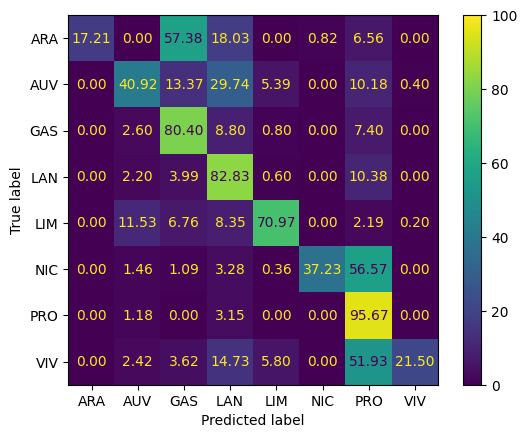

Predict and evaluate with model concatnowiki-train
Computed all predictions in 0:00:21.003409


Classification report:
              precision    recall  f1-score   support

         ara     1.0000    0.0738    0.1374       122
         auv     1.0000    0.0040    0.0080       501
         gas     0.6509    0.6340    0.6424       500
         lan     0.2260    0.9681    0.3665       501
         lim     0.5114    0.2227    0.3102       503
         nic        nan    0.0000    0.0000       274
         pro     0.6565    0.5945    0.6240       508
         viv        nan    0.0000    0.0000       414

    accuracy                         0.3692      3323
   macro avg     0.6741    0.3121    0.2610      3323
weighted avg     0.6271    0.3692    0.3005      3323





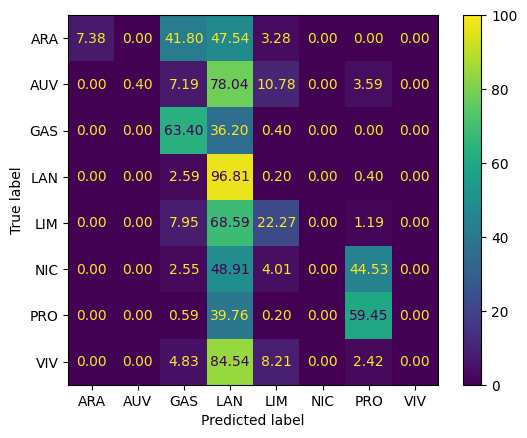

Predict and evaluate with model wiki-train
Computed all predictions in 0:00:21.060053


Classification report:
              precision    recall  f1-score   support

         ara     0.9722    0.2869    0.4430       122
         auv     0.8522    0.3912    0.5363       501
         gas     0.6421    0.7680    0.6995       500
         lan     0.4879    0.8463    0.6190       501
         lim     0.8631    0.7018    0.7741       503
         nic     0.9932    0.5292    0.6905       274
         pro     0.5203    0.9606    0.6750       508
         viv     1.0000    0.2343    0.3796       414

    accuracy                         0.6386      3323
   macro avg     0.7914    0.5898    0.6021      3323
weighted avg     0.7510    0.6386    0.6203      3323





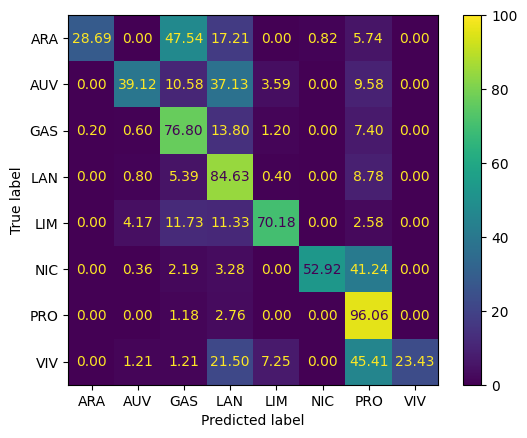

Predict and evaluate with model congres-train
Computed all predictions in 0:00:20.964904


Classification report:
              precision    recall  f1-score   support

         ara     1.0000    0.1148    0.2059       122
         auv     1.0000    0.0020    0.0040       501
         gas     0.5345    0.6500    0.5866       500
         lan     0.1799    0.9062    0.3003       501
         lim     0.5172    0.0298    0.0564       503
         nic        nan    0.0000    0.0000       274
         pro     0.2770    0.0807    0.1250       508
         viv        nan    0.0000    0.0000       414

    accuracy                         0.2558      3323
   macro avg     0.5848    0.2229    0.1598      3323
weighted avg     0.5242    0.2558    0.1693      3323





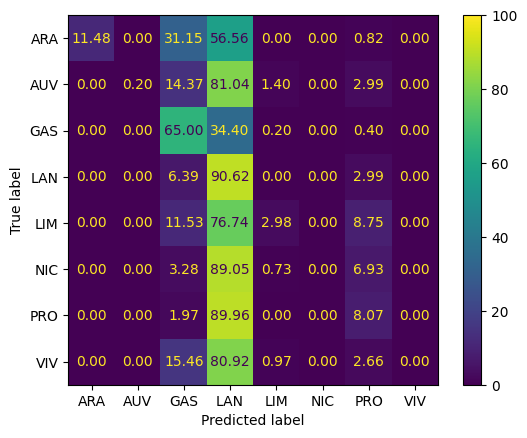

Predict and evaluate with model soft-train
Computed all predictions in 0:00:21.268092


Classification report:
              precision    recall  f1-score   support

         ara        nan    0.0000    0.0000       122
         auv     1.0000    0.0060    0.0119       501
         gas     0.9815    0.2120    0.3487       500
         lan     0.1621    1.0000    0.2790       501
         lim     1.0000    0.0040    0.0079       503
         nic     0.0000    0.0000    0.0000       274
         pro     0.7522    0.1673    0.2738       508
         viv     0.0000    0.0000    0.0000       414

    accuracy                         0.2098      3323
   macro avg     0.5565    0.1737    0.1152      3323
weighted avg     0.6117    0.2098    0.1394      3323





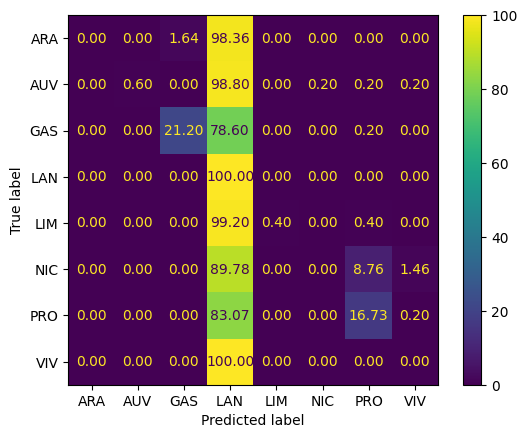

Predict and evaluate with model ttb-train
Computed all predictions in 0:00:20.738172


Classification report:
              precision    recall  f1-score   support

         ara        nan    0.0000    0.0000       122
         auv        nan    0.0000    0.0000       501
         gas     0.5405    0.4800    0.5085       500
         lan     0.1892    0.9760    0.3169       501
         lim     0.5172    0.0298    0.0564       503
         nic        nan    0.0000    0.0000       274
         pro     0.7623    0.3976    0.5226       508
         viv        nan    0.0000    0.0000       414

    accuracy                         0.2847      3323
   macro avg     0.5023    0.2354    0.1756      3323
weighted avg     0.5032    0.2847    0.2127      3323





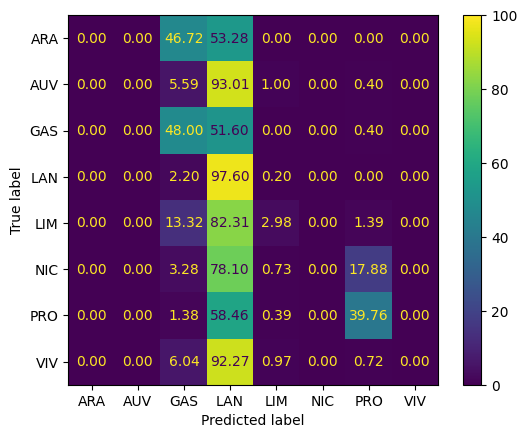

Predict and evaluate with model forum-train
Computed all predictions in 0:00:21.300014


Classification report:
              precision    recall  f1-score   support

         ara        nan    0.0000    0.0000       122
         auv        nan    0.0000    0.0000       501
         gas     0.4577    0.7680    0.5736       500
         lan     0.4750    0.6267    0.5404       501
         lim     0.3070    0.6421    0.4154       503
         nic        nan    0.0000    0.0000       274
         pro     0.5162    0.7835    0.6224       508
         viv        nan    0.0000    0.0000       414

    accuracy                         0.4270      3323
   macro avg     0.4390    0.3525    0.2690      3323
weighted avg     0.4391    0.4270    0.3258      3323





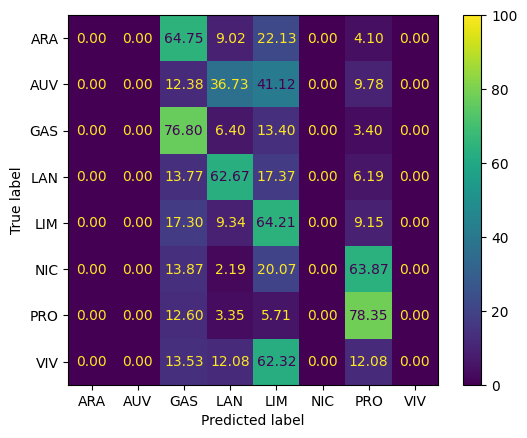

,f1_macro,accuracy,precision_macro,recall_macro,f1_ara,f1_auv,f1_gas,f1_lan,f1_lim,f1_nic,...,precision_viv,recall_ara,recall_auv,recall_gas,recall_lan,recall_lim,recall_nic,recall_pro,recall_viv,speed_avg
wiki-train,0.602117,0.638580,0.791368,0.589791,0.443038,0.536252,0.699454,0.618978,0.774123,0.690476,...,1.000000,0.286885,0.391218,0.768,0.846307,0.701789,0.529197,0.960630,0.234300,6.337663
concat-train,0.561512,0.625038,0.770982,0.558416,0.293706,0.507426,0.723672,0.659253,0.776931,0.541114,...,0.967391,0.172131,0.409182,0.804,0.828343,0.709742,0.372263,0.956693,0.214976,6.347987
forum-train,0.268976,0.427024,0.438993,0.352545,0.000000,0.000000,0.573562,0.540448,0.415434,0.000000,...,NaN,0.000000,0.000000,0.768,0.626747,0.642147,0.000000,0.783465,0.000000,6.409875
concatnowiki-train,0.261047,0.369245,0.674144,0.312122,0.137405,0.007952,0.642351,0.366453,0.310249,0.000000,...,NaN,0.073770,0.003992,0.634,0.968064,0.222664,0.000000,0.594488,0.000000,6.320617
ttb-train,0.175552,0.284683,0.502304,0.235438,0.000000,0.000000,0.508475,0.316915,0.056391,0.000000,...,NaN,0.000000,0.000000,0.480,0.976048,0.029821,0.000000,0.397638,0.000000,6.240798
congres-train,0.159771,0.255793,0.584792,0.222933,0.205882,0.003984,0.586643,0.300265,0.056391,0.000000,...,NaN,0.114754,0.001996,0.650,0.906188,0.029821,0.000000,0.080709,0.000000,6.309029
baseline_random,0.120662,0.125000,0.125000,0.125000,0.056757,0.136680,0.136556,0.136680,0.136927,0.099365,...,0.124586,0.125000,0.125000,0.125,0.125000,0.125000,0.125000,0.125000,0.125000,NaN
soft-train,0.115162,0.209750,0.556547,0.173661,0.000000,0.011905,0.348684,0.279031,0.007921,0.000000,...,0.000000,0.000000,0.005988,0.212,1.000000,0.003976,0.000000,0.167323,0.000000,6.400268


In [27]:
test_name = "wiki"
all_results_alltestsets[test_name] = evaluate_all_models_on_testset(test_name, train_clfs)
show_results_table(all_results_alltestsets[test_name])

## congres - test

Predict and evaluate with model concat-train
Computed all predictions in 0:00:01.997364


Classification report:
              precision    recall  f1-score   support

         ara     0.8889    0.2500    0.3902        32
         auv     0.5000    0.0833    0.1429        24
         gas     0.8044    0.8720    0.8369       500
         lan     0.7259    0.8900    0.7996       500
         lim     0.8375    0.4963    0.6233       135
       other     0.0000       nan    0.0000         0
         pro     0.7848    0.5210    0.6263       119
         viv        nan    0.0000    0.0000        18

    accuracy                         0.7681      1328
   macro avg     0.6488    0.4447    0.4274      1328
weighted avg     0.7726    0.7681    0.7476      1328





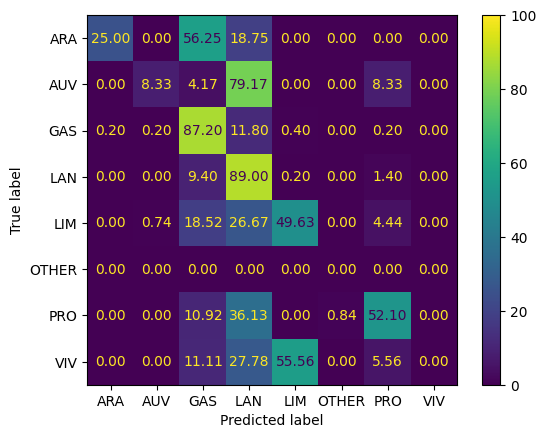

Predict and evaluate with model concatnowiki-train
Computed all predictions in 0:00:01.951444


Classification report:
              precision    recall  f1-score   support

         ara     0.8000    0.1250    0.2162        32
         auv     0.0000    0.0000    0.0000        24
         gas     0.7737    0.8820    0.8243       500
         lan     0.7099    0.8760    0.7842       500
         lim     0.8082    0.4370    0.5673       135
       other     0.0000       nan    0.0000         0
         pro     0.8197    0.4202    0.5556       119
         viv        nan    0.0000    0.0000        18

    accuracy                         0.7470      1328
   macro avg     0.5588    0.3915    0.3685      1328
weighted avg     0.7435    0.7470    0.7183      1328





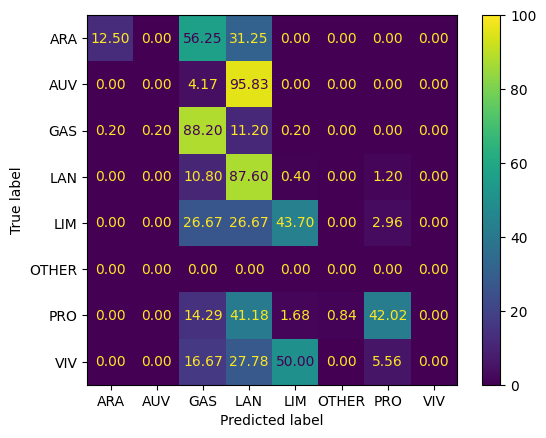

Predict and evaluate with model wiki-train
Computed all predictions in 0:00:01.997679


Classification report:
              precision    recall  f1-score   support

         ara     1.0000    0.3438    0.5116        32
         auv     0.1600    0.1667    0.1633        24
         gas     0.8860    0.7460    0.8100       500
         lan     0.7347    0.7420    0.7383       500
         lim     0.9038    0.3481    0.5027       135
         pro     0.2834    0.7479    0.4111       119
         viv        nan    0.0000    0.0000        18

    accuracy                         0.6739      1328
   macro avg     0.6613    0.4421    0.4481      1328
weighted avg     0.7648    0.6739    0.6862      1328





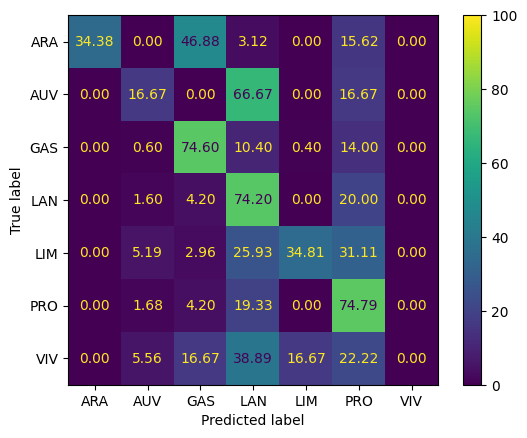

Predict and evaluate with model congres-train
Computed all predictions in 0:00:02.016785


Classification report:
              precision    recall  f1-score   support

         ara     0.8182    0.2812    0.4186        32
         auv     0.0000    0.0000    0.0000        24
         gas     0.7968    0.8940    0.8426       500
         lan     0.6799    0.9260    0.7841       500
         lim     0.6486    0.1778    0.2791       135
         pro     0.7568    0.2353    0.3590       119
         viv        nan    0.0000    0.0000        18

    accuracy                         0.7312      1328
   macro avg     0.6167    0.3592    0.3833      1328
weighted avg     0.7192    0.7312    0.6831      1328





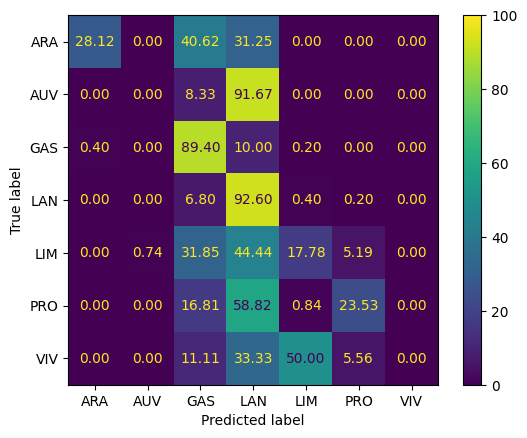

Predict and evaluate with model soft-train
Computed all predictions in 0:00:01.976253


Classification report:
              precision    recall  f1-score   support

         ara        nan    0.0000    0.0000        32
         auv        nan    0.0000    0.0000        24
         gas     0.9776    0.2620    0.4132       500
         lan     0.4232    0.9920    0.5933       500
         lim     1.0000    0.0370    0.0714       135
       other     0.0000       nan    0.0000         0
         pro     0.6667    0.0672    0.1221       119
         viv     0.0000    0.0000    0.0000        18

    accuracy                         0.4819      1328
   macro avg     0.5112    0.1940    0.1500      1328
weighted avg     0.7191    0.4819    0.3972      1328





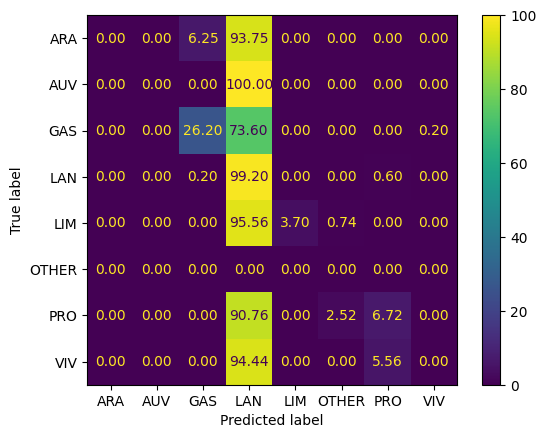

Predict and evaluate with model ttb-train
Computed all predictions in 0:00:01.989803


Classification report:
              precision    recall  f1-score   support

         ara        nan    0.0000    0.0000        32
         auv        nan    0.0000    0.0000        24
         gas     0.7902    0.7080    0.7468       500
         lan     0.5651    0.9460    0.7076       500
         lim     1.0000    0.1556    0.2692       135
         pro     0.8182    0.1513    0.2553       119
         viv        nan    0.0000    0.0000        18

    accuracy                         0.6521      1328
   macro avg     0.7934    0.2801    0.2827      1328
weighted avg     0.7257    0.6521    0.5978      1328





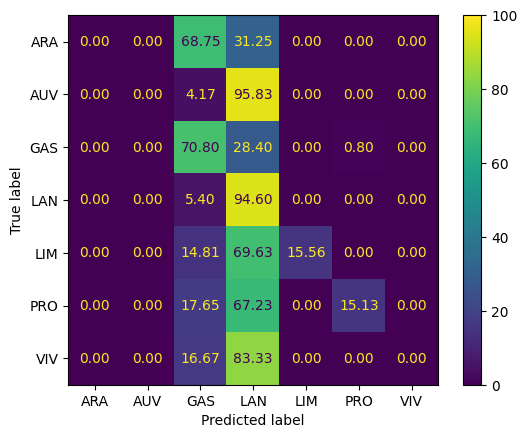

Predict and evaluate with model forum-train
Computed all predictions in 0:00:01.968968


Classification report:
              precision    recall  f1-score   support

         ara        nan    0.0000    0.0000        32
         auv        nan    0.0000    0.0000        24
         gas     0.7018    0.8660    0.7753       500
         lan     0.8132    0.6180    0.7023       500
         lim     0.4526    0.7778    0.5722       135
         pro     0.5455    0.4538    0.4954       119
         viv        nan    0.0000    0.0000        18

    accuracy                         0.6785      1328
   macro avg     0.6282    0.3879    0.3636      1328
weighted avg     0.7045    0.6785    0.6589      1328





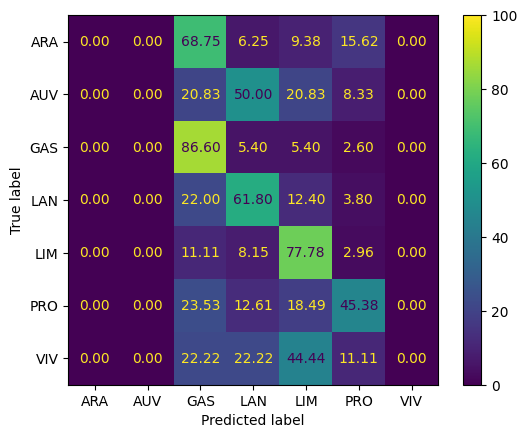

,f1_macro,accuracy,precision_macro,recall_macro,f1_ara,f1_auv,f1_gas,f1_lan,f1_lim,f1_pro,...,recall_auv,recall_gas,recall_lan,recall_lim,recall_pro,recall_viv,f1_other,precision_other,recall_other,speed_avg
wiki-train,0.448136,0.673946,0.661321,0.442066,0.511628,0.163265,0.809989,0.738308,0.502674,0.411085,...,0.166667,0.746000,0.742000,0.348148,0.747899,0.000000,NaN,NaN,NaN,1.504276
concat-train,0.427389,0.768072,0.648795,0.444663,0.390244,0.142857,0.836852,0.799641,0.623256,0.626263,...,0.083333,0.872000,0.890000,0.496296,0.521008,0.000000,0.0,0.0,NaN,1.504039
congres-train,0.383333,0.731175,0.616710,0.359189,0.418605,0.000000,0.842601,0.784081,0.279070,0.358974,...,0.000000,0.894000,0.926000,0.177778,0.235294,0.000000,NaN,NaN,NaN,1.518663
concatnowiki-train,0.368453,0.746988,0.558780,0.391458,0.216216,0.000000,0.824299,0.784244,0.567308,0.555556,...,0.000000,0.882000,0.876000,0.437037,0.420168,0.000000,0.0,0.0,NaN,1.469461
forum-train,0.363598,0.678464,0.628245,0.387937,0.000000,0.000000,0.775291,0.702273,0.572207,0.495413,...,0.000000,0.866000,0.618000,0.777778,0.453782,0.000000,NaN,NaN,NaN,1.482657
ttb-train,0.282706,0.652108,0.793368,0.280117,0.000000,0.000000,0.746835,0.707554,0.269231,0.255319,...,0.000000,0.708000,0.946000,0.155556,0.151261,0.000000,NaN,NaN,NaN,1.498346
soft-train,0.150015,0.481928,0.511248,0.194038,0.000000,0.000000,0.413249,0.593301,0.071429,0.122137,...,0.000000,0.262000,0.992000,0.037037,0.067227,0.000000,0.0,0.0,NaN,1.488142
baseline_random,0.105893,0.142857,0.142857,0.142857,0.041237,0.032086,0.207125,0.207125,0.118786,0.110134,...,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857,NaN,NaN,NaN,NaN


In [28]:
test_name = "congres"
all_results_alltestsets[test_name] = evaluate_all_models_on_testset(test_name, train_clfs)
show_results_table(all_results_alltestsets[test_name])

## soft - test

Predict and evaluate with model concat-train
Computed all predictions in 0:00:01.136643


Classification report:
              precision    recall  f1-score   support

         auv     0.3818    0.2692    0.3158        78
         gas     0.8316    0.7990    0.8150       204
         lan     0.4134    0.9500    0.5761       500
         lim     0.6176    0.5164    0.5625       122
         nic     0.8143    0.2280    0.3563       500
       other     0.0000       nan    0.0000         0
         pro     0.7356    0.3840    0.5046       500
         viv     0.2564    0.2564    0.2564        78

    accuracy                         0.5288      1982
   macro avg     0.5064    0.4862    0.4233      1982
weighted avg     0.6440    0.5288    0.5035      1982





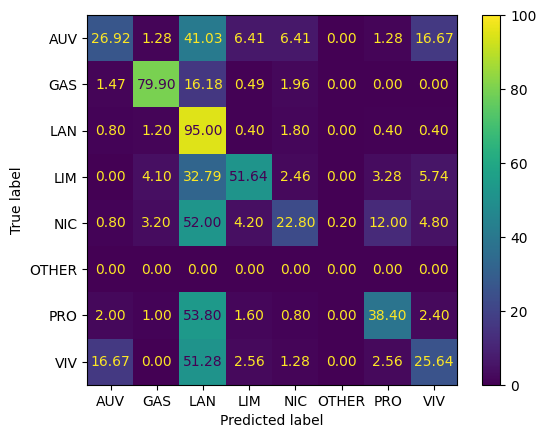

Predict and evaluate with model concatnowiki-train
Computed all predictions in 0:00:01.142812


Classification report:
              precision    recall  f1-score   support

         auv     0.1974    0.1923    0.1948        78
         gas     0.7710    0.8088    0.7895       204
         lan     0.4021    0.9160    0.5589       500
         lim     0.5577    0.4754    0.5133       122
         nic     0.7547    0.1600    0.2640       500
       other     0.0000       nan    0.0000         0
         pro     0.7368    0.3640    0.4873       500
         viv     0.1684    0.2051    0.1850        78

    accuracy                         0.4914      1982
   macro avg     0.4485    0.4460    0.3741      1982
weighted avg     0.6058    0.4914    0.4583      1982





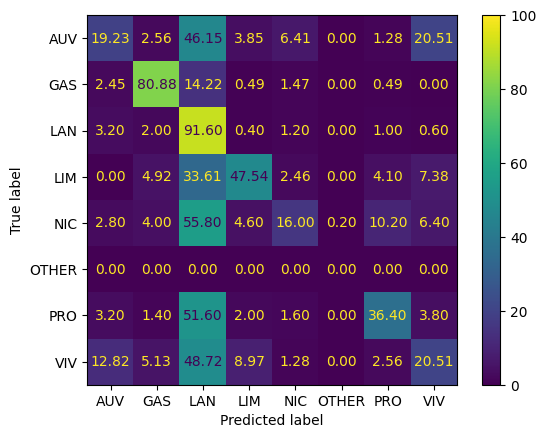

Predict and evaluate with model wiki-train
Computed all predictions in 0:00:01.148939


Classification report:
              precision    recall  f1-score   support

         auv     0.5581    0.3077    0.3967        78
         gas     0.5546    0.6471    0.5973       204
         lan     0.4276    0.6200    0.5061       500
         lim     0.6170    0.2377    0.3432       122
         nic     1.0000    0.1220    0.2175       500
       other     0.0000       nan    0.0000         0
         pro     0.3542    0.6120    0.4487       500
         viv     0.6667    0.0256    0.0494        78

    accuracy                         0.4359      1982
   macro avg     0.5223    0.3674    0.3199      1982
weighted avg     0.5928    0.4359    0.3959      1982





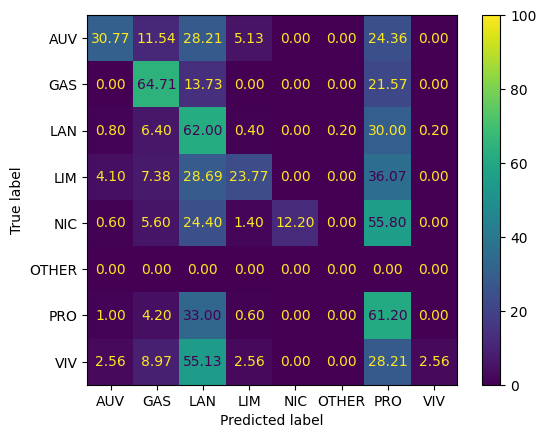

Predict and evaluate with model congres-train
Computed all predictions in 0:00:01.137320


Classification report:
              precision    recall  f1-score   support

         auv     0.0000    0.0000    0.0000        78
         gas     0.3245    0.8382    0.4679       204
         lan     0.2865    0.7880    0.4203       500
         lim     0.4571    0.1311    0.2038       122
         nic        nan    0.0000    0.0000       500
       other     0.0000       nan    0.0000         0
         pro     0.3243    0.0240    0.0447       500
         viv        nan    0.0000    0.0000        78

    accuracy                         0.2992      1982
   macro avg     0.2321    0.2545    0.1421      1982
weighted avg     0.3044    0.2992    0.1780      1982





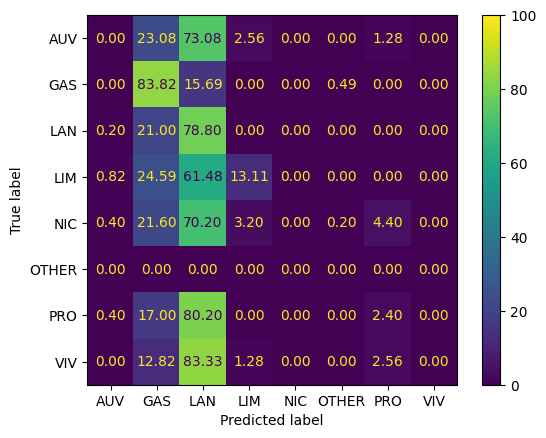

Predict and evaluate with model soft-train
Computed all predictions in 0:00:01.128759


Classification report:
              precision    recall  f1-score   support

         auv     0.1935    0.2308    0.2105        78
         gas     0.7215    0.5588    0.6298       204
         lan     0.3776    0.8760    0.5277       500
         lim     0.4590    0.4590    0.4590       122
         nic     0.7518    0.2120    0.3307       500
         pro     0.7451    0.3040    0.4318       500
         viv     0.1442    0.1923    0.1648        78

    accuracy                         0.4536      1982
   macro avg     0.4847    0.4047    0.3935      1982
weighted avg     0.5887    0.4536    0.4333      1982





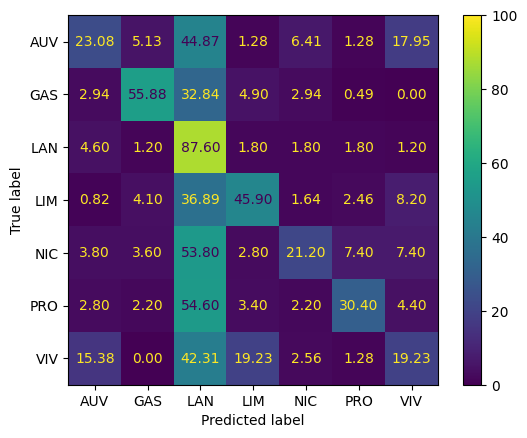

Predict and evaluate with model ttb-train
Computed all predictions in 0:00:01.134343


Classification report:
              precision    recall  f1-score   support

         auv        nan    0.0000    0.0000        78
         gas     0.4720    0.5784    0.5198       204
         lan     0.2892    0.9480    0.4432       500
         lim     0.2800    0.0574    0.0952       122
         nic        nan    0.0000    0.0000       500
         pro     0.6912    0.0940    0.1655       500
         viv        nan    0.0000    0.0000        78

    accuracy                         0.3259      1982
   macro avg     0.4331    0.2397    0.1748      1982
weighted avg     0.4681    0.3259    0.2129      1982





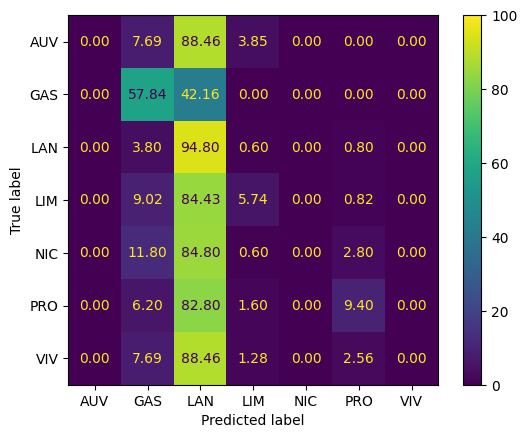

Predict and evaluate with model forum-train
Computed all predictions in 0:00:01.219433


Classification report:
              precision    recall  f1-score   support

         auv        nan    0.0000    0.0000        78
         gas     0.3080    0.8333    0.4497       204
         lan     0.4337    0.5100    0.4688       500
         lim     0.1732    0.5820    0.2669       122
         nic        nan    0.0000    0.0000       500
         pro     0.3981    0.3440    0.3691       500
         viv        nan    0.0000    0.0000        78

    accuracy                         0.3370      1982
   macro avg     0.3282    0.3242    0.2221      1982
weighted avg     0.3770    0.3370    0.2741      1982





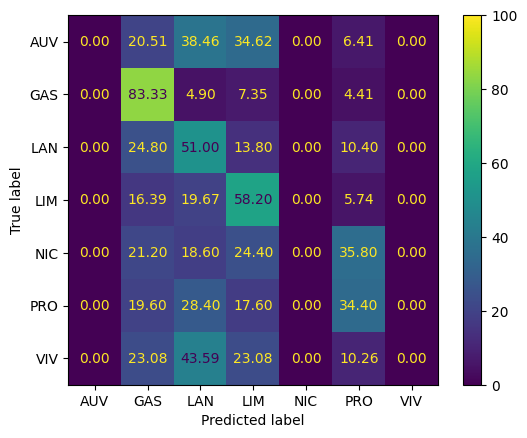

,f1_macro,accuracy,precision_macro,recall_macro,f1_auv,f1_gas,f1_lan,f1_lim,f1_nic,f1_pro,...,recall_gas,recall_lan,recall_lim,recall_nic,recall_pro,recall_viv,f1_other,precision_other,recall_other,speed_avg
concat-train,0.423332,0.528759,0.506354,0.486151,0.315789,0.815000,0.576107,0.562500,0.356250,0.504599,...,0.799020,0.950000,0.516393,0.228000,0.384000,0.256410,0.0,0.0,NaN,0.573483
soft-train,0.393496,0.453582,0.484682,0.404702,0.210526,0.629834,0.527711,0.459016,0.330733,0.431818,...,0.558824,0.876000,0.459016,0.212000,0.304000,0.192308,NaN,NaN,NaN,0.569505
concatnowiki-train,0.374089,0.491423,0.448522,0.445953,0.194805,0.789474,0.558877,0.513274,0.264026,0.487282,...,0.808824,0.916000,0.475410,0.160000,0.364000,0.205128,0.0,0.0,NaN,0.576595
wiki-train,0.319854,0.435923,0.522275,0.367442,0.396694,0.597285,0.506122,0.343195,0.217469,0.448680,...,0.647059,0.620000,0.237705,0.122000,0.612000,0.025641,0.0,0.0,NaN,0.579687
forum-train,0.222072,0.337033,0.328241,0.324186,0.000000,0.449735,0.468750,0.266917,0.000000,0.369099,...,0.833333,0.510000,0.581967,0.000000,0.344000,0.000000,NaN,NaN,NaN,0.615254
ttb-train,0.174822,0.325933,0.433094,0.239687,0.000000,0.519824,0.443198,0.095238,0.000000,0.165493,...,0.578431,0.948000,0.057377,0.000000,0.094000,0.000000,NaN,NaN,NaN,0.572322
congres-train,0.142079,0.299193,0.232082,0.254483,0.000000,0.467852,0.420267,0.203822,0.000000,0.044693,...,0.838235,0.788000,0.131148,0.000000,0.024000,0.000000,0.0,0.0,NaN,0.573824
baseline_random,0.125193,0.142857,0.142857,0.142857,0.061709,0.119648,0.182415,0.086037,0.182415,0.182415,...,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857,NaN,NaN,NaN,NaN


In [29]:
test_name = "soft"
all_results_alltestsets[test_name] = evaluate_all_models_on_testset(test_name, train_clfs)
show_results_table(all_results_alltestsets[test_name])

## ttb - test

Predict and evaluate with model concat-train
Computed all predictions in 0:00:00.627685


Classification report:
              precision    recall  f1-score   support

         gas     0.7387    0.7961    0.7664       103
         lan     0.9057    0.9016    0.9037       437
         lim     0.8387    0.6341    0.7222        41
       other     0.0000       nan    0.0000         0
         pro     0.6176    0.6562    0.6364        32

    accuracy                         0.8532       613
   macro avg     0.6202    0.7470    0.6057       613
weighted avg     0.8582    0.8532    0.8545       613





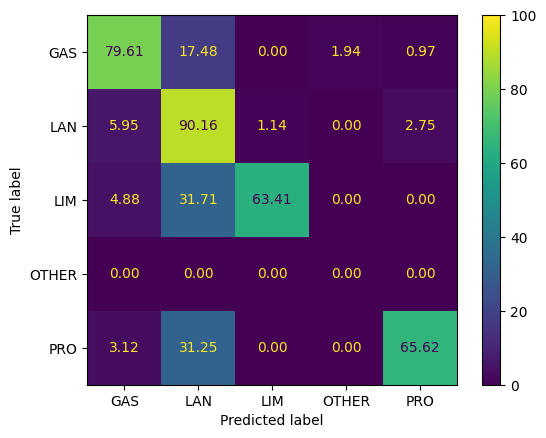

Predict and evaluate with model concatnowiki-train
Computed all predictions in 0:00:00.614338


Classification report:
              precision    recall  f1-score   support

         gas     0.7358    0.7573    0.7464       103
         lan     0.8976    0.9222    0.9097       437
         lim     0.8333    0.6098    0.7042        41
       other     0.0000       nan    0.0000         0
         pro     0.7200    0.5625    0.6316        32

    accuracy                         0.8548       613
   macro avg     0.6373    0.7129    0.5984       613
weighted avg     0.8568    0.8548    0.8540       613





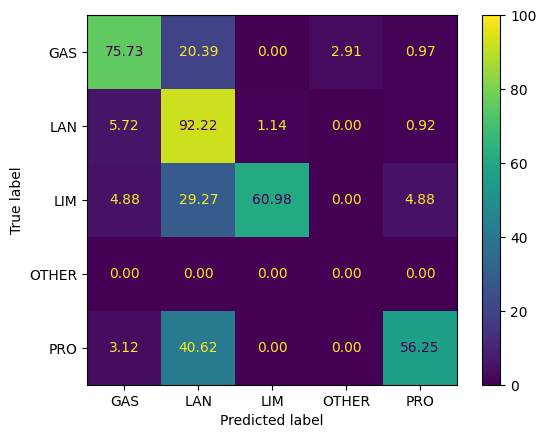

Predict and evaluate with model wiki-train
Computed all predictions in 0:00:00.635362


Classification report:
              precision    recall  f1-score   support

         gas     0.7064    0.7476    0.7264       103
         lan     0.9167    0.6796    0.7806       437
         lim     0.9231    0.2927    0.4444        41
       other     0.0000       nan    0.0000         0
         pro     0.1534    0.7812    0.2564        32

    accuracy                         0.6705       613
   macro avg     0.5399    0.6253    0.4416       613
weighted avg     0.8419    0.6705    0.7216       613





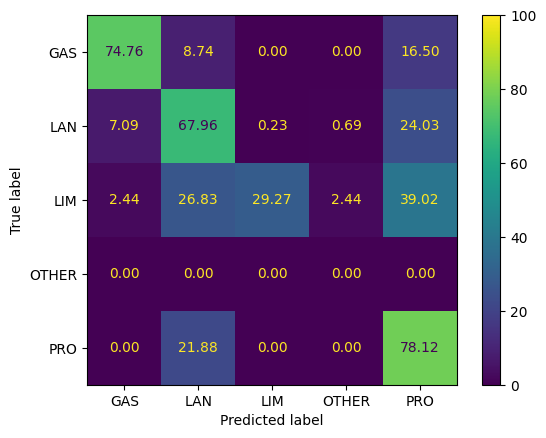

Predict and evaluate with model congres-train
Computed all predictions in 0:00:00.615540


Classification report:
              precision    recall  f1-score   support

         gas     0.4247    0.7670    0.5467       103
         lan     0.8345    0.7963    0.8150       437
         lim     1.0000    0.0732    0.1364        41
       other     0.0000       nan    0.0000         0
         pro     0.7500    0.0938    0.1667        32

    accuracy                         0.7064       613
   macro avg     0.6019    0.4326    0.3329       613
weighted avg     0.7723    0.7064    0.6907       613





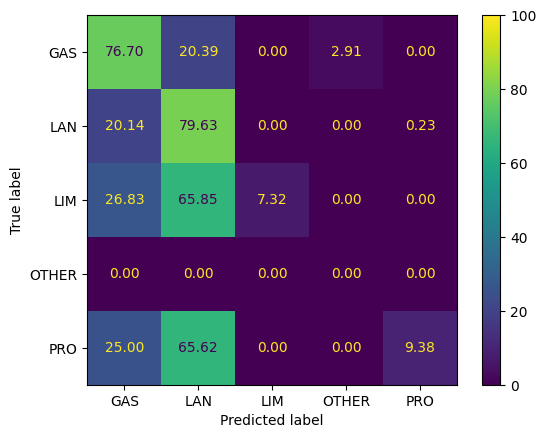

Predict and evaluate with model soft-train
Computed all predictions in 0:00:00.620369


Classification report:
              precision    recall  f1-score   support

         gas     1.0000    0.1359    0.2393       103
         lan     0.7381    0.9931    0.8468       437
         lim     1.0000    0.0244    0.0476        41
       other     0.0000       nan    0.0000         0
         pro     0.3333    0.0938    0.1463        32

    accuracy                         0.7374       613
   macro avg     0.6143    0.3118    0.2560       613
weighted avg     0.7785    0.7374    0.6547       613





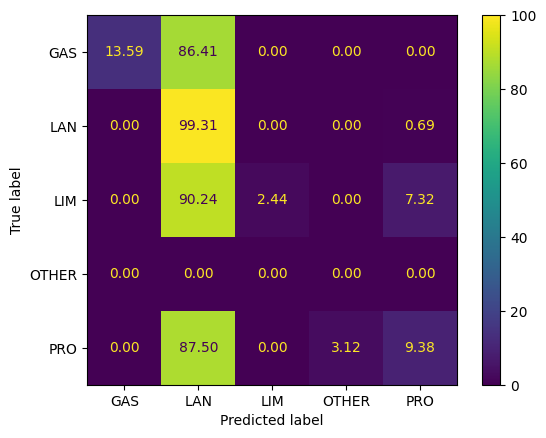

Predict and evaluate with model ttb-train
Computed all predictions in 0:00:00.608293


Classification report:
              precision    recall  f1-score   support

         gas     0.9189    0.6602    0.7684       103
         lan     0.8520    0.9748    0.9093       437
         lim     0.8500    0.4146    0.5574        41
         pro     0.5789    0.3438    0.4314        32

    accuracy                         0.8515       613
   macro avg     0.8000    0.5984    0.6666       613
weighted avg     0.8489    0.8515    0.8371       613





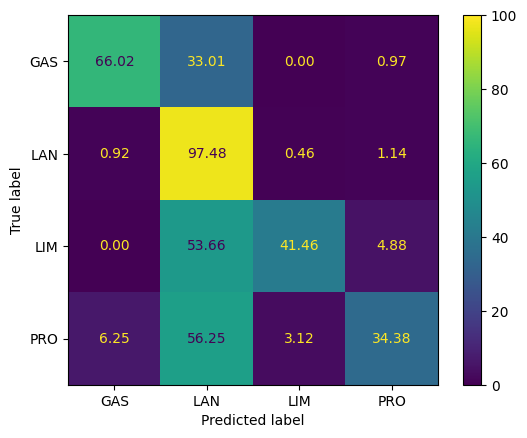

Predict and evaluate with model forum-train
Computed all predictions in 0:00:00.611276


Classification report:
              precision    recall  f1-score   support

         gas     0.5592    0.8252    0.6667       103
         lan     0.9758    0.5538    0.7066       437
         lim     0.3058    0.9024    0.4568        41
         pro     0.2174    0.6250    0.3226        32

    accuracy                         0.6264       613
   macro avg     0.5145    0.7266    0.5382       613
weighted avg     0.8214    0.6264    0.6631       613





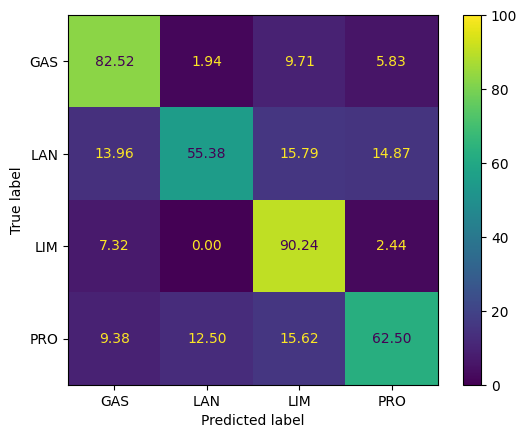

,f1_macro,accuracy,precision_macro,recall_macro,f1_gas,f1_lan,f1_lim,f1_pro,precision_gas,precision_lan,precision_lim,precision_pro,recall_gas,recall_lan,recall_lim,recall_pro,f1_other,precision_other,recall_other,speed_avg
ttb-train,0.666599,0.851550,0.799967,0.598352,0.768362,0.909285,0.557377,0.431373,0.918919,0.852000,0.850000,0.578947,0.660194,0.974828,0.414634,0.34375,NaN,NaN,NaN,0.992321
concat-train,0.605722,0.853181,0.620169,0.747029,0.766355,0.903670,0.722222,0.636364,0.738739,0.905747,0.838710,0.617647,0.796117,0.901602,0.634146,0.65625,0.0,0.0,NaN,1.023956
concatnowiki-train,0.598384,0.854812,0.637347,0.712934,0.746411,0.909707,0.704225,0.631579,0.735849,0.897550,0.833333,0.720000,0.757282,0.922197,0.609756,0.56250,0.0,0.0,NaN,1.002183
forum-train,0.538152,0.626427,0.514548,0.726614,0.666667,0.706569,0.456790,0.322581,0.559211,0.975806,0.305785,0.217391,0.825243,0.553776,0.902439,0.62500,NaN,NaN,NaN,0.997188
wiki-train,0.441564,0.670473,0.539908,0.625285,0.726415,0.780552,0.444444,0.256410,0.706422,0.916667,0.923077,0.153374,0.747573,0.679634,0.292683,0.78125,0.0,0.0,NaN,1.036480
congres-train,0.332946,0.706362,0.601853,0.432562,0.546713,0.814988,0.136364,0.166667,0.424731,0.834532,1.000000,0.750000,0.766990,0.796339,0.073171,0.09375,0.0,0.0,NaN,1.004144
soft-train,0.256021,0.737357,0.614286,0.311799,0.239316,0.846829,0.047619,0.146341,1.000000,0.738095,1.000000,0.333333,0.135922,0.993135,0.024390,0.09375,0.0,0.0,NaN,1.012021
baseline_random,0.190765,0.250000,0.250000,0.250000,0.200976,0.370182,0.105534,0.086370,0.168026,0.712887,0.066884,0.052202,0.250000,0.250000,0.250000,0.25000,NaN,NaN,NaN,NaN


In [30]:
test_name = "ttb"
all_results_alltestsets[test_name] = evaluate_all_models_on_testset(test_name, train_clfs)
show_results_table(all_results_alltestsets[test_name])

## forum - test

Predict and evaluate with model concat-train
Computed all predictions in 0:00:04.344949


Classification report:
              precision    recall  f1-score   support

         gas     0.9024    0.8880    0.8952       250
         lan     0.7821    0.8760    0.8264       250
         lim     0.8244    0.9200    0.8696       250
       other     0.0000       nan    0.0000         0
         pro     0.9845    0.7600    0.8578       250

    accuracy                         0.8610      1000
   macro avg     0.6987    0.8610    0.6898      1000
weighted avg     0.8734    0.8610    0.8622      1000





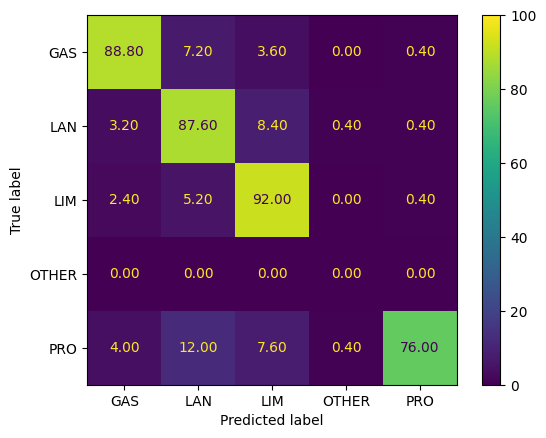

Predict and evaluate with model concatnowiki-train
Computed all predictions in 0:00:04.386616


Classification report:
              precision    recall  f1-score   support

         gas     0.8849    0.8920    0.8884       250
         lan     0.7591    0.8320    0.7939       250
         lim     0.8156    0.9200    0.8647       250
         pro     0.9688    0.7440    0.8416       250

    accuracy                         0.8470      1000
   macro avg     0.8571    0.8470    0.8472      1000
weighted avg     0.8571    0.8470    0.8472      1000





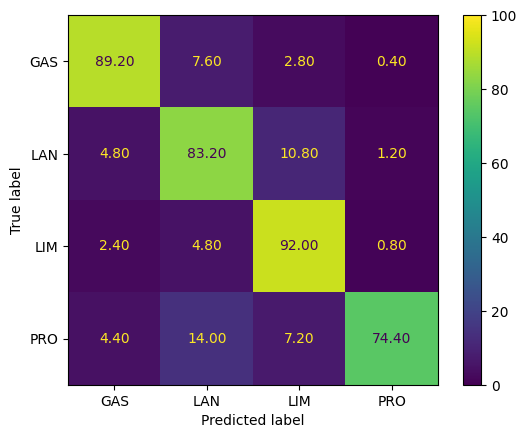

Predict and evaluate with model wiki-train
Computed all predictions in 0:00:04.356660


Classification report:
              precision    recall  f1-score   support

         gas     0.8297    0.7600    0.7933       250
         lan     0.5876    0.8720    0.7021       250
         lim     0.9528    0.4840    0.6419       250
       other     0.0000       nan    0.0000         0
         pro     0.7235    0.7640    0.7432       250

    accuracy                         0.7200      1000
   macro avg     0.6187    0.7200    0.5761      1000
weighted avg     0.7734    0.7200    0.7201      1000





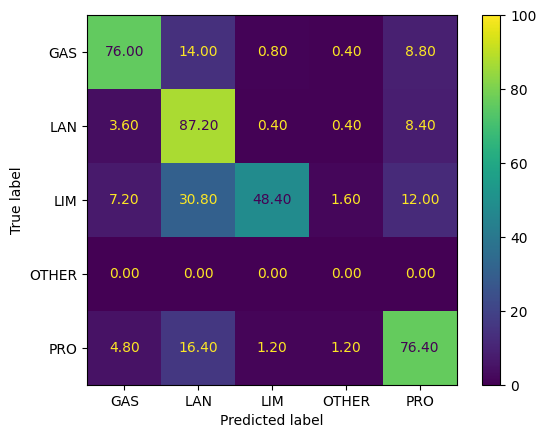

Predict and evaluate with model congres-train
Computed all predictions in 0:00:04.431112


Classification report:
              precision    recall  f1-score   support

         gas     0.6862    0.7960    0.7370       250
         lan     0.3447    0.9280    0.5027       250
         lim     1.0000    0.0720    0.1343       250
         pro     0.6842    0.0520    0.0967       250

    accuracy                         0.4620      1000
   macro avg     0.6788    0.4620    0.3677      1000
weighted avg     0.6788    0.4620    0.3677      1000





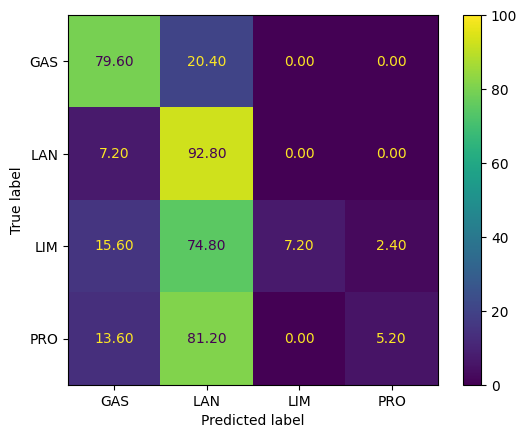

Predict and evaluate with model soft-train
Computed all predictions in 0:00:04.467090


Classification report:
              precision    recall  f1-score   support

         gas     1.0000    0.1680    0.2877       250
         lan     0.2742    0.9960    0.4301       250
         lim     1.0000    0.0600    0.1132       250
       other     0.0000       nan    0.0000         0
         pro     0.7500    0.0960    0.1702       250

    accuracy                         0.3300      1000
   macro avg     0.6048    0.3300    0.2002      1000
weighted avg     0.7561    0.3300    0.2503      1000





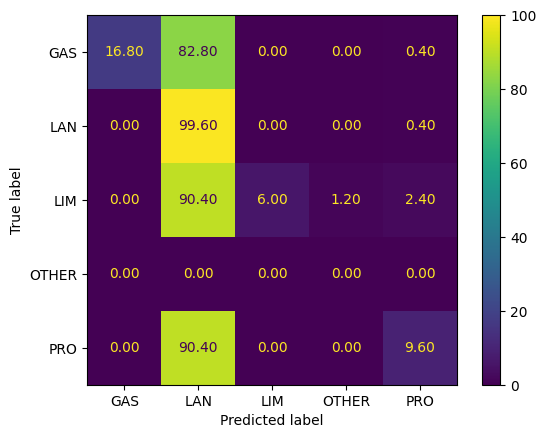

Predict and evaluate with model ttb-train
Computed all predictions in 0:00:04.357422


Classification report:
              precision    recall  f1-score   support

         gas     0.8204    0.6760    0.7412       250
         lan     0.3548    0.9680    0.5193       250
         lim     0.8793    0.2040    0.3312       250
         pro     0.8519    0.1840    0.3026       250

    accuracy                         0.5080      1000
   macro avg     0.7266    0.5080    0.4736      1000
weighted avg     0.7266    0.5080    0.4736      1000





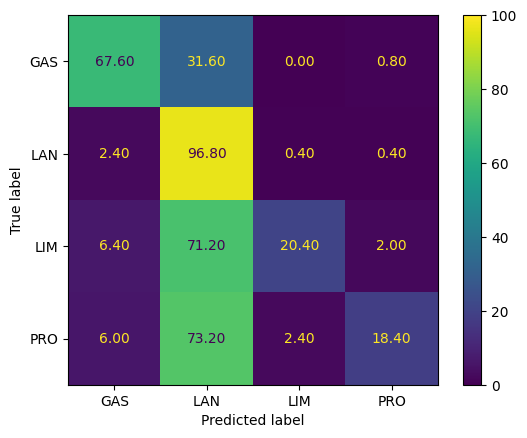

Predict and evaluate with model forum-train
Computed all predictions in 0:00:04.370836


Classification report:
              precision    recall  f1-score   support

         gas     0.9076    0.9040    0.9058       250
         lan     0.8610    0.8920    0.8762       250
         lim     0.8304    0.9400    0.8818       250
         pro     0.9809    0.8200    0.8932       250

    accuracy                         0.8890      1000
   macro avg     0.8950    0.8890    0.8893      1000
weighted avg     0.8950    0.8890    0.8893      1000





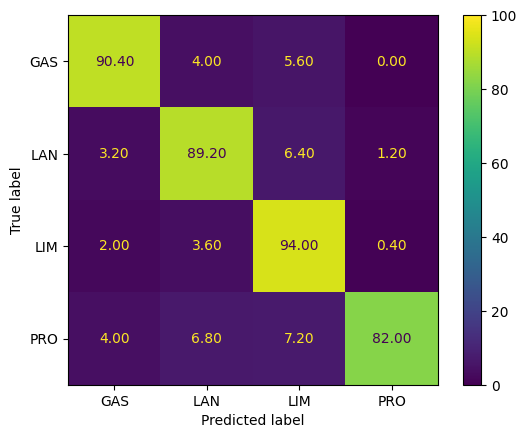

,f1_macro,accuracy,precision_macro,recall_macro,f1_gas,f1_lan,f1_lim,f1_pro,precision_gas,precision_lan,precision_lim,precision_pro,recall_gas,recall_lan,recall_lim,recall_pro,f1_other,precision_other,recall_other,speed_avg
forum-train,0.889272,0.889,0.894971,0.889,0.905812,0.876228,0.881801,0.893246,0.907631,0.861004,0.830389,0.980861,0.904,0.892,0.940,0.820,NaN,NaN,NaN,4.370836
concatnowiki-train,0.847157,0.847,0.857099,0.847,0.888446,0.793893,0.864662,0.841629,0.884921,0.759124,0.815603,0.968750,0.892,0.832,0.920,0.744,NaN,NaN,NaN,4.386616
concat-train,0.689786,0.861,0.698682,0.861,0.895161,0.826415,0.869565,0.857788,0.902439,0.782143,0.824373,0.984456,0.888,0.876,0.920,0.760,0.0,0.0,NaN,4.344949
wiki-train,0.576103,0.720,0.618707,0.720,0.793319,0.702093,0.641910,0.743191,0.829694,0.587601,0.952756,0.723485,0.760,0.872,0.484,0.764,0.0,0.0,NaN,4.356660
ttb-train,0.473585,0.508,0.726597,0.508,0.741228,0.519313,0.331169,0.302632,0.820388,0.354839,0.879310,0.851852,0.676,0.968,0.204,0.184,NaN,NaN,NaN,4.357422
congres-train,0.367682,0.462,0.678786,0.462,0.737037,0.502709,0.134328,0.096654,0.686207,0.344725,1.000000,0.684211,0.796,0.928,0.072,0.052,NaN,NaN,NaN,4.431112
baseline_random,0.250000,0.250,0.250000,0.250,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250,0.250,0.250,0.250,NaN,NaN,NaN,NaN
soft-train,0.200229,0.330,0.604846,0.330,0.287671,0.430052,0.113208,0.170213,1.000000,0.274229,1.000000,0.750000,0.168,0.996,0.060,0.096,0.0,0.0,NaN,4.467090


In [31]:
test_name = "forum"
all_results_alltestsets[test_name] = evaluate_all_models_on_testset(test_name, train_clfs)
show_results_table(all_results_alltestsets[test_name])

# Aggregate scores

In [32]:
# Reorder results dict
datasets_order = ["concat", "wiki", "congres", "soft", "ttb", "forum"]
all_results_alltestsets = {ds_name: all_results_alltestsets[ds_name] for ds_name in datasets_order}

In [33]:
def aggregate_mean_std(name_patterns, 
                       all_results_alltestsets, 
                       best_metric="f1_macro", 
                       result_index_name="Training dataset"):
    results_avg_patterns = {}
    for pattern_name in name_patterns:
        # Get best scores for each testset
        results_rows = {}   
        for test_name, res_dict in all_results_alltestsets.items():
            best_scores = None
            for model_name, scores in res_dict.items():
                if pattern_name not in model_name:
                    continue
                if not best_scores or scores[best_metric] > best_scores[best_metric]:
                    best_scores = scores
            results_rows[test_name] = best_scores
        # Concatenate results
        df_pattern = pd.DataFrame.from_dict(
            results_rows, orient="index"
        )
        # Compute average and std
        scores_avg = df_pattern.mean(axis=0, skipna=True)
        scores_std = df_pattern.std(axis=0, skipna=True)
    
        # Merge into a DataFrame with 1 row and all columns (add suffix _avg or _std)
        scores_avg = pd.DataFrame([scores_avg]).add_suffix('_avg')
        scores_std = pd.DataFrame([scores_std]).add_suffix('_std')
        scores_avg = pd.concat([scores_avg, scores_std], axis=1)
        scores_avg.index = [pattern_name]
        
        # Store results
        results_avg_patterns[pattern_name] = scores_avg
    
    df_results_avg_patterns = pd.concat(results_avg_patterns.values()).sort_values(best_metric+"_avg", ascending=False)
    df_results_avg_patterns.index.name = result_index_name
    return df_results_avg_patterns

In [34]:
# Per training dataset
# Average over best per testset + std
df_results_avg_train = aggregate_mean_std(
    train_datasets, 
    all_results_alltestsets,
    result_index_name="Training dataset")
pd.set_option("display.max_columns", None)
df_results_avg_train

,f1_macro_avg,accuracy_avg,precision_macro_avg,recall_macro_avg,f1_ara_avg,f1_auv_avg,f1_gas_avg,f1_lan_avg,f1_lim_avg,f1_nic_avg,f1_pro_avg,f1_viv_avg,precision_ara_avg,precision_auv_avg,precision_gas_avg,precision_lan_avg,precision_lim_avg,precision_nic_avg,precision_pro_avg,precision_viv_avg,recall_ara_avg,recall_auv_avg,recall_gas_avg,recall_lan_avg,recall_lim_avg,recall_nic_avg,recall_pro_avg,recall_viv_avg,speed_avg_avg,f1_other_avg,precision_other_avg,recall_other_avg,f1_macro_std,accuracy_std,precision_macro_std,recall_macro_std,f1_ara_std,f1_auv_std,f1_gas_std,f1_lan_std,f1_lim_std,f1_nic_std,f1_pro_std,f1_viv_std,precision_ara_std,precision_auv_std,precision_gas_std,precision_lan_std,precision_lim_std,precision_nic_std,precision_pro_std,precision_viv_std,recall_ara_std,recall_auv_std,recall_gas_std,recall_lan_std,recall_lim_std,recall_nic_std,recall_pro_std,recall_viv_std,speed_avg_std,f1_other_std,precision_other_std,recall_other_std
Training dataset,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
concat,0.569944,0.715426,0.687759,0.600742,0.330820,0.359165,0.805034,0.741831,0.718020,0.440436,0.647163,0.232194,0.913943,0.543130,0.780434,0.658978,0.797652,0.895403,0.697799,0.621659,0.203481,0.284964,0.833548,0.882043,0.663921,0.293111,0.656150,0.171278,2.906166,0.0,0.0,NaN,0.155082,0.129686,0.123166,0.159783,0.051992,0.166400,0.056942,0.115824,0.109363,0.093529,0.108537,0.159807,0.076664,0.128820,0.078865,0.173995,0.089539,0.088807,0.170960,0.355892,0.041091,0.147206,0.040946,0.045870,0.155097,0.073149,0.195308,0.115895,2.257017,0.0,0.0,NaN
wiki,0.567659,0.685595,0.695720,0.588124,0.468549,0.346657,0.777879,0.711684,0.670087,0.457876,0.600453,0.222302,0.964074,0.484796,0.774115,0.643528,0.806807,0.911171,0.610242,0.719474,0.309779,0.280417,0.785760,0.833151,0.598305,0.318449,0.693169,0.158386,2.894879,0.0,0.0,NaN,0.163097,0.141976,0.146812,0.163447,0.037518,0.194809,0.067083,0.128365,0.143205,0.215850,0.151865,0.169344,0.040618,0.357315,0.096041,0.185877,0.125762,0.135545,0.246256,0.477252,0.030007,0.117290,0.057274,0.079848,0.198016,0.190074,0.204977,0.106943,2.254485,0.0,0.0,NaN
concatnowiki,0.469761,0.643825,0.622408,0.512581,0.168261,0.063153,0.776557,0.666323,0.585005,0.148546,0.626092,0.059466,0.840741,0.353140,0.761298,0.570895,0.701647,0.751190,0.775171,0.168421,0.094395,0.056123,0.793372,0.904114,0.520897,0.087786,0.534822,0.059125,2.881868,0.0,0.0,NaN,0.215414,0.201604,0.138811,0.215755,0.042096,0.090452,0.082405,0.198763,0.186855,0.135083,0.119017,0.087306,0.143300,0.442128,0.075444,0.256338,0.140656,0.004988,0.108366,0.000000,0.027034,0.091640,0.094420,0.046018,0.231892,0.081129,0.134558,0.098452,2.252074,0.0,0.0,NaN
forum,0.428869,0.579114,0.553528,0.504705,0.000000,0.000000,0.670938,0.652575,0.513805,0.000000,0.544407,0.000000,NaN,NaN,0.578849,0.697904,0.406076,NaN,0.531283,NaN,0.000000,0.000000,0.838372,0.635721,0.762986,0.000000,0.604800,0.000000,2.899011,NaN,NaN,NaN,0.251186,0.196857,0.194398,0.241194,0.000000,0.000000,0.157958,0.143357,0.206541,0.000000,0.205173,0.000000,NaN,NaN,0.206520,0.219720,0.227071,NaN,0.252509,NaN,0.000000,0.000000,0.045261,0.133473,0.140879,0.000000,0.184102,0.000000,2.267794,NaN,NaN,NaN
ttb,0.330406,0.507545,0.646175,0.349988,0.000000,0.000000,0.653642,0.565896,0.248965,0.000000,0.338367,0.000000,NaN,NaN,0.701566,0.431223,0.708674,NaN,0.743239,NaN,0.000000,0.000000,0.618689,0.962414,0.161167,0.000000,0.233433,0.000000,2.859737,NaN,NaN,NaN,0.199342,0.214027,0.153939,0.160803,0.000000,0.000000,0.117278,0.210551,0.182852,0.000000,0.127179,0.000000,NaN,NaN,0.172634,0.240187,0.266327,NaN,0.097639,NaN,0.000000,0.000000,0.082369,0.013031,0.139443,0.000000,0.116433,0.000000,2.220536,NaN,NaN,NaN
congres,0.265060,0.475968,0.530322,0.328958,0.291496,0.001814,0.639286,0.550611,0.156593,0.000000,0.151547,0.000000,0.861616,0.281250,0.554817,0.443200,0.707664,NaN,0.531373,NaN,0.181785,0.000914,0.788238,0.868131,0.092705,0.000000,0.092433,0.000000,2.913443,0.0,0.0,NaN,0.10

In [35]:
def get_metric_matrix(train_datasets, 
                      all_results_alltestsets, 
                      metric="f1_macro"):
    scores_matrix = {}
    # Get scores for each model (training dataset)
    for train_data in train_datasets:
        # Get scores for each testset
        train_scores = []

        for test_name, test_scores in all_results_alltestsets.items():
            model_name = f"{train_data}-train"
            if model_name in test_scores:
                test_score = test_scores[model_name][metric]
            else:
                test_score = None
            train_scores.append(test_score)
        scores_matrix[train_data] = train_scores
    
    # Put in a DataFrame
    df_matrix = pd.DataFrame.from_dict(scores_matrix, orient="index", columns=list(all_results_alltestsets))
    df_matrix *= 100
    
    return df_matrix

df_metric_matrix = get_metric_matrix(
    [ds for ds in train_datasets if ds != "concatnowiki"], 
    all_results_alltestsets)
df_metric_matrix

,concat,wiki,congres,soft,ttb,forum
concat,55.454864,56.151200,42.738904,42.333196,60.572214,68.978588
wiki,53.607336,60.211669,44.813572,31.985361,44.156434,57.610266
congres,20.454606,15.977057,38.333305,14.207916,33.294628,36.768206
soft,20.572544,11.516159,15.001458,39.349634,25.602120,20.022867
ttb,20.917143,17.555247,28.270566,17.482180,66.659903,47.358545
forum,29.114652,26.897565,36.359766,22.207164,53.815169,88.927171


In [36]:
def get_metric_baseline(all_results_alltestsets, metric="f1_macro", baseline_name="baseline_random"):
    scores = {}
    # Get baseline score for each test set
    for test_name, test_scores in all_results_alltestsets.items():
        baseline_score = test_scores[baseline_name][metric]
        scores[test_name] = baseline_score
    # Put in a DataFrame
    df_baseline = pd.DataFrame(scores, index=[baseline_name])
    df_baseline *= 100
    return df_baseline

df_baseline = get_metric_baseline(all_results_alltestsets)
df_baseline

,concat,wiki,congres,soft,ttb,forum
baseline_random,11.321189,12.06621,10.589316,12.519257,19.07654,25.0


In [37]:
# F1-macro + P&R per dialect, on concat (train+test)
model_results = all_results_alltestsets["concat"]["concat-train"]

# Get F1-macro
dialect_results = {"f1_macro": model_results["f1_macro"]}

# Get precision and recall per dialect
dialects = [metric.replace("f1_", "") for metric in model_results if metric.startswith("f1_") and not metric.endswith("macro")]
for dia in dialects:
    dialect_results[f"precision_{dia}"] = model_results[f"precision_{dia}"]
    dialect_results[f"recall_{dia}"] = model_results[f"recall_{dia}"]

# Get average runtime per sample (in ms/sample)
dialect_results["speed_avg"] = model_results["speed_avg"]

df_per_dialect = pd.DataFrame(dialect_results, index=["svm"])
df_per_dialect.loc[:, df_per_dialect.columns != 'speed_avg'] *= 100
df_per_dialect

,f1_macro,precision_ara,recall_ara,precision_auv,recall_auv,precision_gas,recall_gas,precision_lan,recall_lan,precision_lim,recall_lim,precision_nic,recall_nic,precision_pro,recall_pro,precision_viv,recall_viv,speed_avg
svm,55.454864,85.294118,18.831169,62.295082,37.810945,76.494725,83.815029,60.216383,89.031079,81.828194,70.694577,88.163265,27.906977,60.11378,67.494677,64.117647,21.372549,3.600914


In [38]:
# F1-macro + P&R per dialect, for the random baseline evaluated on concat-test
# baseline_random
model_results = all_results_alltestsets["concat"]["baseline_random"]
dialects = [metric.replace("f1_", "") for metric in model_results if metric.startswith("f1_") and not metric.endswith("macro")]
dialect_results = {
    "f1_macro": model_results["f1_macro"], 
    "recall_macro": model_results["recall_macro"], 
    "precision_macro": model_results["precision_macro"],
    "accuracy": model_results["accuracy"]
}
for dia in dialects:
    dialect_results[f"precision_{dia}"] = model_results[f"precision_{dia}"]
    dialect_results[f"recall_{dia}"] = model_results[f"recall_{dia}"]

df_per_dialect = pd.DataFrame(dialect_results, index=["baseline_random"])
df_per_dialect.loc[:, df_per_dialect.columns != 'speed_avg'] *= 100
df_per_dialect

,f1_macro,recall_macro,precision_macro,accuracy,precision_ara,recall_ara,precision_auv,recall_auv,precision_gas,recall_gas,precision_lan,recall_lan,precision_lim,recall_lim,precision_nic,recall_nic,precision_pro,recall_pro,precision_viv,recall_viv
baseline_random,11.321189,12.5,12.5,12.5,1.867572,12.5,7.312636,12.5,18.881882,12.5,26.534077,12.5,12.745574,12.5,9.386369,12.5,17.087073,12.5,6.184817,12.5


In [39]:
# Export all scores to JSON
with open(scores_path, "w") as f:
    json.dump(all_results_alltestsets, f, indent=4)